# Libraries

In [ ]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os
import gc
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import f1_score
import lightgbm as lgb
import seaborn as sns
from sklearn.impute import KNNImputer
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score, roc_curve, auc)
from sklearn.preprocessing import label_binarize
from catboost import CatBoostClassifier
import optuna
from optuna.samplers import TPESampler
from pyproj import Transformer
from imblearn.combine import SMOTETomek
from imblearn.over_sampling import SMOTE




sns.set(style="whitegrid")

# Load Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
# =============================================================================
# 1. Load All Datasets Efficiently
# =============================================================================



def load_csv(path):
    """
    Load CSV file with accident_index stored as string
    to prevent datatype inconsistencies during merging.
    """
    return pd.read_csv(
        path,
        low_memory=False,
        dtype={'accident_index': 'string'}
    )

print("Loading datasets...")

df_main = load_csv('/content/drive/MyDrive/severity_analysis.csv')
df_spatial = load_csv('/content/drive/MyDrive/spatial_analysis.csv')
df_demographic = load_csv('/content/drive/MyDrive/demographic_analysis.csv')
df_temporal = load_csv('/content/drive/MyDrive/temporal_analysis.csv')
df_risk = load_csv('/content/drive/MyDrive/risk_factors_analysis.csv')

print("Datasets loaded successfully.")

# =============================================================================
# 2. Add Sequence Numbers to Casualty-Level Datasets
# =============================================================================

casualty_dfs = [df_main, df_spatial, df_demographic, df_risk]

for dataset in casualty_dfs:
    dataset['seq'] = dataset.groupby('accident_index', observed=True).cumcount()

print("Sequence identifiers added to casualty-level datasets.")

# =============================================================================
# 3. Validate Row Counts for Data Alignment
# =============================================================================

reference_counts = df_main.groupby('accident_index', observed=True).size()
alignment_status = True

for name, dataset in zip(['spatial', 'demographic', 'risk'], casualty_dfs[1:]):
    counts = dataset.groupby('accident_index', observed=True).size()

    if not reference_counts.equals(counts):
        print(f"Row count mismatch detected in {name} dataset.")
        alignment_status = False

if alignment_status:
    print("Row counts across casualty-level datasets are consistent.")

# =============================================================================
# 4. Merge Casualty-Level Datasets
# =============================================================================

df_casualty = df_main.copy()

for dataset in casualty_dfs[1:]:
    df_casualty = df_casualty.merge(
        dataset,
        on=['accident_index', 'seq'],
        how='left',
        suffixes=('', '_duplicate')
    )

    duplicate_columns = [col for col in df_casualty.columns if col.endswith('_duplicate')]
    df_casualty.drop(columns=duplicate_columns, inplace=True, errors='ignore')

print("Casualty-level datasets merged successfully.")
print("Current dataset shape:", df_casualty.shape)

# =============================================================================
# 5. Validate Data Alignment
# =============================================================================

if 'casualty_age' in df_casualty.columns and 'age_band_of_casualty' in df_casualty.columns:

    sample_data = df_casualty[['casualty_age', 'age_band_of_casualty']] \
        .dropna() \
        .sample(min(1000, len(df_casualty)))

    print("Sample verification of casualty age alignment:")
    print(sample_data.head())

else:
    print("Age validation skipped due to missing columns.")

# =============================================================================
# 6. Merge Accident-Level Temporal Data
# =============================================================================

df_temporal = df_temporal.drop_duplicates(subset='accident_index')

df_final = df_casualty.merge(
    df_temporal,
    on='accident_index',
    how='left'
)

print("Temporal dataset merged.")
print("Dataset shape after temporal merge:", df_final.shape)

# =============================================================================
# 7. Cleanup and Memory Optimization
# =============================================================================

del df_casualty, df_temporal, df_main, df_spatial, df_demographic, df_risk
gc.collect()

if 'seq' in df_final.columns:
    df_final.drop(columns=['seq'], inplace=True)

print("Data preparation completed.")
print("Final dataset shape:", df_final.shape)
print("Total number of columns:", len(df_final.columns))

Loading datasets...
Datasets loaded successfully.
Sequence identifiers added to casualty-level datasets.
Row counts across casualty-level datasets are consistent.
Casualty-level datasets merged successfully.
Current dataset shape: (1221287, 28)
Sample verification of casualty age alignment:
         casualty_age age_band_of_casualty
254546           33.0              26 - 35
668222           26.0              26 - 35
1144216          72.0              66 - 75
937047           62.0              56 - 65
44065            39.0              36 - 45
Temporal dataset merged.
Dataset shape after temporal merge: (1221287, 37)
Data preparation completed.
Final dataset shape: (1221287, 36)
Total number of columns: 36


We loaded this CSV to obtain vehicle type (car, motorcycle, etc.) for the Car Details section, and merged it with accident severity so we can analyze how vehicle type relates to accident outcomes.



# Understand the data

In [ ]:
df_final.head()

,accident_index,accident_severity_x,casualty_severity,enhanced_severity_collision,enhanced_casualty_severity,longitude,latitude,location_easting_osgr,location_northing_osgr,road_type,...,driver_distance_banding,accident_year,date,time,hour,day_of_week,month,season,number_of_casualties,accident_severity_y
0,2020170S30810,Serious,Serious,-1,Data missing or out of range,NaN,NaN,445240.0,517608.0,Single carriageway,...,-1,2020,2020-06-28,04:55,4,Sun,Jun,Summer,1,Serious
1,2020170S31410,Slight,Slight,-1,Data missing or out of range,NaN,NaN,445551.0,516373.0,Single carriageway,...,-1,2020,2020-10-18,03:15,3,Sun,Oct,Autumn,1,Slight
2,2020170S31410,Slight,Slight,-1,Data missing or out of range,NaN,NaN,445551.0,516373.0,Single carriageway,...,-1,2020,2020-10-18,03:15,3,Sun,Oct,Autumn,1,Slight
3,2020170S31410,Slight,Slight,-1,Data missing or out of range,NaN,NaN,445551.0,516373.0,Single carriageway,...,-1,2020,2020-10-18,03:15,3,Sun,Oct,Autumn,1,Slight
4,2020170S11520,Slight,Slight,-1,Data missing or out of range,NaN,NaN,444050.0,518602.0,Single carriageway,...,-1,2020,2020-10-26,19:01,19,Mon,Oct,Autumn,1,Slight


In [ ]:
df_final.columns

Index(['accident_index', 'accident_severity_x', 'casualty_severity',
       'enhanced_severity_collision', 'enhanced_casualty_severity',
       'longitude', 'latitude', 'location_easting_osgr',
       'location_northing_osgr', 'road_type', 'speed_limit',
       'urban_or_rural_area', 'driver_age', 'driver_sex', 'casualty_age',
       'casualty_sex', 'casualty_class', 'casualty_type', 'age_band_of_driver',
       'age_band_of_casualty', 'weather_conditions', 'light_conditions',
       'road_surface_conditions', 'junction_control',
       'towing_and_articulation', 'vehicle_type', 'driver_distance_banding',
       'accident_year', 'date', 'time', 'hour', 'day_of_week', 'month',
       'season', 'number_of_casualties', 'accident_severity_y'],
      dtype='object')

In [ ]:
df_final.describe()

,enhanced_severity_collision,longitude,latitude,location_easting_osgr,location_northing_osgr,driver_age,casualty_age,accident_year,hour,number_of_casualties
count,1.221287e+06,16.0,0.0,1.221143e+06,1.221143e+06,1.060218e+06,1.195748e+06,1.221287e+06,1.221287e+06,1.221287e+06
mean,1.644084e+00,-3.0,NaN,4.539589e+05,2.772031e+05,4.103631e+01,3.809972e+01,2.022043e+03,1.382235e+01,1.791210e+00
std,2.683093e+00,0.0,NaN,9.338432e+04,1.464920e+05,1.668504e+01,1.857721e+01,1.387877e+00,5.073082e+00,1.644730e+00
min,-1.000000e+00,-3.0,NaN,6.594700e+04,1.021100e+04,1.000000e+00,0.000000e+00,2.020000e+03,0.000000e+00,1.000000e+00
25%,-1.000000e+00,-3.0,NaN,3.914985e+05,1.750145e+05,2.800000e+01,2.400000e+01,2.021000e+03,1.000000e+01,1.000000e+00
50%,3.000000e+00,-3.0,NaN,4.587200e+05,2.228510e+05,3.800000e+01,3.500000e+01,2.022000e+03,1.500000e+01,1.000000e+00
75%,3.000000e+00,-3.0,NaN,5.292580e+05,3.848480e+05,5.300000e+01,5.100000e+01,2.023000e+03,1.700000e+01,2.000000e+00
max,7.000000e+00,-3.0,NaN,6.553450e+05,1.184351e+06,1.010000e+02,1.010000e+02,2.024000e+03,2.300000e+01,7.000000e+01


In [ ]:
df_final.dtypes

,0
accident_index,string[python]
accident_severity_x,object
casualty_severity,object
enhanced_severity_collision,int64
enhanced_casualty_severity,object
longitude,float64
latitude,float64
location_easting_osgr,float64
location_northing_osgr,float64
road_type,object


# Data Cleaning

In [ ]:
# ------------------------------------------------
# Drop unnecessary and redundant columns
# ------------------------------------------------

columns_to_drop = [
    'accident_index',
    'casualty_severity',
    'enhanced_casualty_severity',
    'enhanced_severity_collision',
    'number_of_casualties',
    'date',
    'time',
    'age_band_of_driver',
    'age_band_of_casualty',
    'accident_severity_y'
]

df_clean = df_final.drop(columns=columns_to_drop, errors='ignore')

# Rename severity column for clarity
df_clean.rename(columns={'accident_severity_x': 'accident_severity'}, inplace=True)

# ------------------------------------------------
# Check the cleaned dataset
# ------------------------------------------------

print("Cleaned dataset shape:", df_clean.shape)
print("Remaining columns:", df_clean.columns)
df_clean.head()

Cleaned dataset shape: (1221287, 26)
Remaining columns: Index(['accident_severity', 'longitude', 'latitude', 'location_easting_osgr',
       'location_northing_osgr', 'road_type', 'speed_limit',
       'urban_or_rural_area', 'driver_age', 'driver_sex', 'casualty_age',
       'casualty_sex', 'casualty_class', 'casualty_type', 'weather_conditions',
       'light_conditions', 'road_surface_conditions', 'junction_control',
       'towing_and_articulation', 'vehicle_type', 'driver_distance_banding',
       'accident_year', 'hour', 'day_of_week', 'month', 'season'],
      dtype='object')


,accident_severity,longitude,latitude,location_easting_osgr,location_northing_osgr,road_type,speed_limit,urban_or_rural_area,driver_age,driver_sex,...,road_surface_conditions,junction_control,towing_and_articulation,vehicle_type,driver_distance_banding,accident_year,hour,day_of_week,month,season
0,Serious,NaN,NaN,445240.0,517608.0,Single carriageway,20,Urban,65.0,Male,...,Dry,Data missing or out of range,No tow/articulation,Car,-1,2020,4,Sun,Jun,Summer
1,Slight,NaN,NaN,445551.0,516373.0,Single carriageway,30,Urban,NaN,Male,...,Wet or damp,Data missing or out of range,No tow/articulation,Car,-1,2020,3,Sun,Oct,Autumn
2,Slight,NaN,NaN,445551.0,516373.0,Single carriageway,30,Urban,NaN,Female,...,Wet or damp,Data missing or out of range,No tow/articulation,Car,-1,2020,3,Sun,Oct,Autumn
3,Slight,NaN,NaN,445551.0,516373.0,Single carriageway,30,Urban,NaN,Not known,...,Wet or damp,Data missing or out of range,No tow/articulation,Van / Goods 3.5 tonnes mgw or under,-1,2020,3,Sun,Oct,Autumn
4,Slight,NaN,NaN,444050.0,518602.0,Single carriageway,30,Urban,54.0,Male,...,Dry,Give way or uncontrolled,No tow/articulation,Car,-1,2020,19,Mon,Oct,Autumn


Columns were removed based on three criteria: lack of predictive value (identifier variables), risk of data leakage (post-accident outcome variables), and redundancy with existing features. This preprocessing step ensured that the final dataset contained only relevant and independent predictors for accident severity classification

## Check Duplicates

In [ ]:
replace_mapping = {
    'Data missing or out of range': 'Unknown',
    'unknown (self reported)': 'Unknown',
    'Not known': 'Unknown',
    'Unknown': 'Unknown',
    '-1': 'Unknown'
}

categorical_cols = df_clean.select_dtypes(include='object').columns

for col in categorical_cols:
    df_clean[col] = df_clean[col].replace(replace_mapping)

Some categorical columns, like driver_sex, casualty_sex, urban_or_rural_area, and vehicle_type, had entries such as “Data missing or out of range,” “Unknown,” or “Not known.” These are missing or invalid values that could affect analysis or machine learning. To fix this, we replaced all of them with a single "Unknown" category.

## Missing Values Analysis

In [ ]:
df_clean.isna().sum()

,0
accident_severity,0
longitude,1221271
latitude,1221287
location_easting_osgr,144
location_northing_osgr,144
road_type,0
speed_limit,0
urban_or_rural_area,0
driver_age,161069
driver_sex,0


In [ ]:
  (df_clean.isnull().sum() / len(df_clean)) * 100


,0
accident_severity,0.000000
longitude,99.998690
latitude,100.000000
location_easting_osgr,0.011791
location_northing_osgr,0.011791
road_type,0.000000
speed_limit,0.000000
urban_or_rural_area,0.000000
driver_age,13.188464
driver_sex,0.000000


In [ ]:
df_clean = df_clean.drop(columns=['longitude','latitude'])

Longitude and latitude were removed because more than 99% of their values were missing, making them unsuitable for analysis or machine learning.

In [ ]:
# KNN finds the nearest similar locations and fills with their average
imputer = KNNImputer(n_neighbors=5)
df_clean[['location_easting_osgr', 'location_northing_osgr']] = imputer.fit_transform(
    df_clean[['location_easting_osgr', 'location_northing_osgr']]
)

 We use KNN because these are geographic coordinates and KNN will intelligently fill missing locations based on nearby similar accident locations, which makes much more geographic sense than a simple median

In [ ]:
# Impute missing values with 0 (or you could use median if preferred)
df_clean['driver_age'] = df_clean['driver_age'].fillna(0)
df_clean['casualty_age'] = df_clean['casualty_age'].fillna(0)

# Verify
print("Driver age - min:", df_clean['driver_age'].min(), "max:", df_clean['driver_age'].max())
print("Casualty age - min:", df_clean['casualty_age'].min(), "max:", df_clean['casualty_age'].max())
print("\nDriver age missing values:", df_clean['driver_age'].isna().sum())
print("Casualty age missing values:", df_clean['casualty_age'].isna().sum())

Driver age - min: 0.0 max: 101.0
Casualty age - min: 0.0 max: 101.0

Driver age missing values: 0
Casualty age missing values: 0


This converts numeric ages into categories to simplify modeling and reduce outlier impact. Missing values are placed in an "Unknown" category instead of being dropped. This keeps the dataset complete and helps models, especially tree-based ones, learn patterns from both age groups and missing data.

In [ ]:
# Verify
df_clean.isna().sum()


,0
accident_severity,0
location_easting_osgr,0
location_northing_osgr,0
road_type,0
speed_limit,0
urban_or_rural_area,0
driver_age,0
driver_sex,0
casualty_age,0
casualty_sex,0


So there is no missing vlaues remaining in this dataset.


## Check Duplicates

In [ ]:
df_clean.duplicated().sum()

np.int64(23882)

In [ ]:
# See a sample of duplicates
dupes = df_clean[df_clean.duplicated(keep=False)]
dupes.head(10)

,accident_severity,location_easting_osgr,location_northing_osgr,road_type,speed_limit,urban_or_rural_area,driver_age,driver_sex,casualty_age,casualty_sex,...,road_surface_conditions,junction_control,towing_and_articulation,vehicle_type,driver_distance_banding,accident_year,hour,day_of_week,month,season
30,Slight,459460.0,306155.0,Dual carriageway,30,Urban,21.0,Male,21.0,Male,...,Wet or damp,Give way or uncontrolled,No tow/articulation,Car,Unknown,2020,4,Fri,May,Spring
31,Slight,459460.0,306155.0,Dual carriageway,30,Urban,21.0,Male,21.0,Male,...,Wet or damp,Give way or uncontrolled,No tow/articulation,Car,Unknown,2020,4,Fri,May,Spring
106,Slight,463828.0,100273.0,Dual carriageway,30,Urban,28.0,Male,28.0,Male,...,Dry,Unknown,No tow/articulation,Car,Unknown,2020,17,Tue,Mar,Spring
108,Slight,463828.0,100273.0,Dual carriageway,30,Urban,28.0,Male,28.0,Male,...,Dry,Unknown,No tow/articulation,Car,Unknown,2020,17,Tue,Mar,Spring
274,Slight,408849.0,282336.0,Dual carriageway,30,Urban,0.0,Unknown,29.0,Male,...,Dry,Give way or uncontrolled,No tow/articulation,Car,Unknown,2020,20,Thu,Jul,Summer
276,Slight,408849.0,282336.0,Dual carriageway,30,Urban,0.0,Unknown,29.0,Male,...,Dry,Give way or uncontrolled,No tow/articulation,Car,Unknown,2020,20,Thu,Jul,Summer
277,Slight,408332.0,285867.0,Dual carriageway,30,Urban,24.0,Male,18.0,Male,...,Dry,Auto traffic signal,No tow/articulation,Car,Unknown,2020,20,Sat,Aug,Summer
279,Slight,408332.0,285867.0,Dual carriageway,30,Urban,24.0,Male,18.0,Male,...,Dry,Auto traffic signal,No tow/articulation,Car,Unknown,2020,20,Sat,Aug,Summer
282,Slight,408332.0,285867.0,Dual carriageway,30,Urban,18.0,Male,18.0,Male,...,Dry,Auto traffic signal,No tow/articulation,Car,Unknown,2020,20,Sat,Aug,Summer
284,Slight,408332.0,285867.0,Dual carriageway,30,Urban,18.0,Male,18.0,Male,...,Dry,Auto traffic signal,No tow/articulation,Car,Unknown,2020,20,Sat,Aug,Summer


In [ ]:
df_backup = df_clean.copy()

In [ ]:
df_clean = df_clean.drop_duplicates()

In [ ]:
print("Removed duplicates:", 103793 - df_clean.duplicated().sum())
print("New shape:", df_clean.shape)

Removed duplicates: 103793
New shape: (1197405, 24)


In [ ]:
df_clean.duplicated().sum()

np.int64(0)

We removed exact full-row duplicates because they are likely redundant entries caused by merge or data errors, which add no new information. This keeps the dataset clean, avoids bias, and preserves only unique, meaningful records for analysis and modeling.

# Exploratory Data Analysis (EDA)

## Accident Severity Analysis

### Distribution of Target Feature

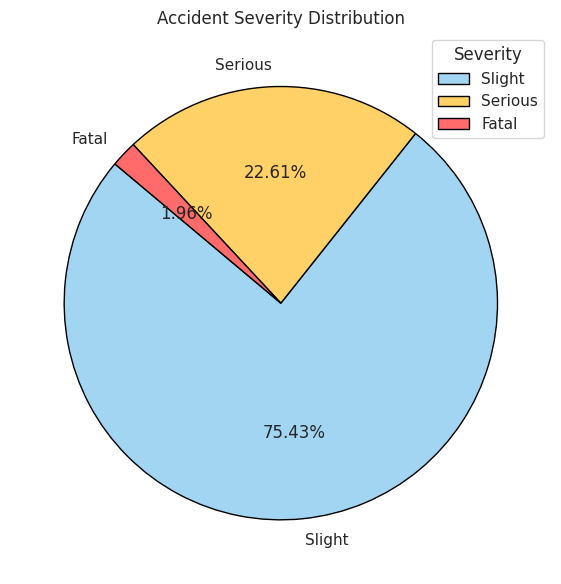

In [ ]:
# Define consistent severity colors for all plots
severity_colors_map = {'Slight': '#A2D5F2', 'Serious': '#FFD166', 'Fatal': '#FF6B6B'}

# Count of each severity
severity_counts = df_clean['accident_severity'].value_counts()
labels = severity_counts.index
sizes = severity_counts.values

# Map colors to labels correctly
colors = [severity_colors_map[s] for s in labels]

# Pie chart with percentages and legend
plt.figure(figsize=(6,6))
plt.pie(sizes, labels=labels, autopct='%1.2f%%', startangle=140, colors=colors, wedgeprops={'edgecolor':'black'})
plt.title("Accident Severity Distribution")

# Add legend
plt.legend(labels, title="Severity", loc="best")
plt.tight_layout()
plt.show()

## Demographics

### Sex of Driver

In [ ]:
severity_order = ['Fatal', 'Serious', 'Slight']

print("\n--- Driver Sex Distribution (Counts) ---")
sex_counts = df_clean['driver_sex'].value_counts()
print(sex_counts)

print("\n--- Accident Severity by Driver Sex (Counts) ---")
sex_severity_counts = df_clean.groupby(['driver_sex', 'accident_severity']).size().unstack(fill_value=0)
# Ensure the columns are in the desired order for consistency
sex_severity_counts = sex_severity_counts[severity_order]
print(sex_severity_counts)

print("\n--- Accident Severity by Driver Sex (Proportions) ---")
# Calculate the proportion of each accident severity for each driver sex
sex_severity_proportion = df_clean.groupby('driver_sex')['accident_severity'].value_counts(normalize=True).unstack(fill_value=0)
# Sort the columns (severity levels) for consistent stacking order
sex_severity_proportion = sex_severity_proportion[severity_order]
print(sex_severity_proportion)


--- Driver Sex Distribution (Counts) ---
driver_sex
Male       751661
Female     320978
Unknown    124766
Name: count, dtype: int64

--- Accident Severity by Driver Sex (Counts) ---
accident_severity  Fatal  Serious  Slight
driver_sex                               
Female              4613    65658  250707
Male               18040   186400  547221
Unknown              788    18683  105295

--- Accident Severity by Driver Sex (Proportions) ---
accident_severity     Fatal   Serious    Slight
driver_sex                                     
Female             0.014372  0.204556  0.781072
Male               0.024000  0.247984  0.728016
Unknown            0.006316  0.149744  0.843940


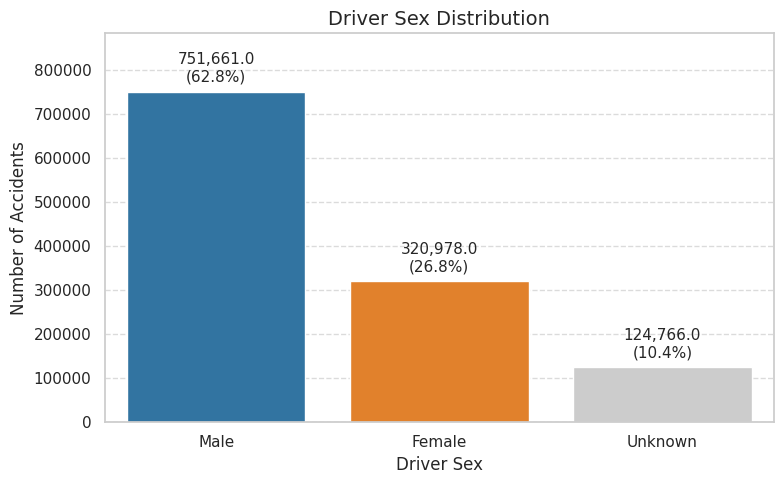

In [ ]:
# Define consistent driver sex colors for all plots
driver_sex_colors_map = {'Male': '#1f77b4', 'Female': '#ff7f0e', 'Unknown': '#cccccc'}

# Overall counts & percentages
sex_counts = df_clean['driver_sex'].value_counts()
total = len(df_clean)

# Count plot with percentages
plt.figure(figsize=(8,5))
ax = sns.countplot(data=df_clean, x='driver_sex', order=sex_counts.index, hue='driver_sex', palette=driver_sex_colors_map, legend=False)

plt.title("Driver Sex Distribution", fontsize=14)
plt.xlabel("Driver Sex", fontsize=12)
plt.ylabel("Number of Accidents", fontsize=12)
plt.xticks(rotation=0, fontsize=11)
plt.yticks(fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.7)

ax.set_ylim(0, ax.get_ylim()[1] * 1.12)

# Annotate each bar with count and percentage
for p in ax.patches:
    height = p.get_height()
    percent = height / total * 100
    ax.annotate(f'{height:,}\n({percent:.1f}%)',
                xy=(p.get_x() + p.get_width() / 2, height),
                xytext=(0,5),
                textcoords='offset points',
                ha='center',
                va='bottom',
                fontsize=11)

plt.tight_layout()
plt.show()

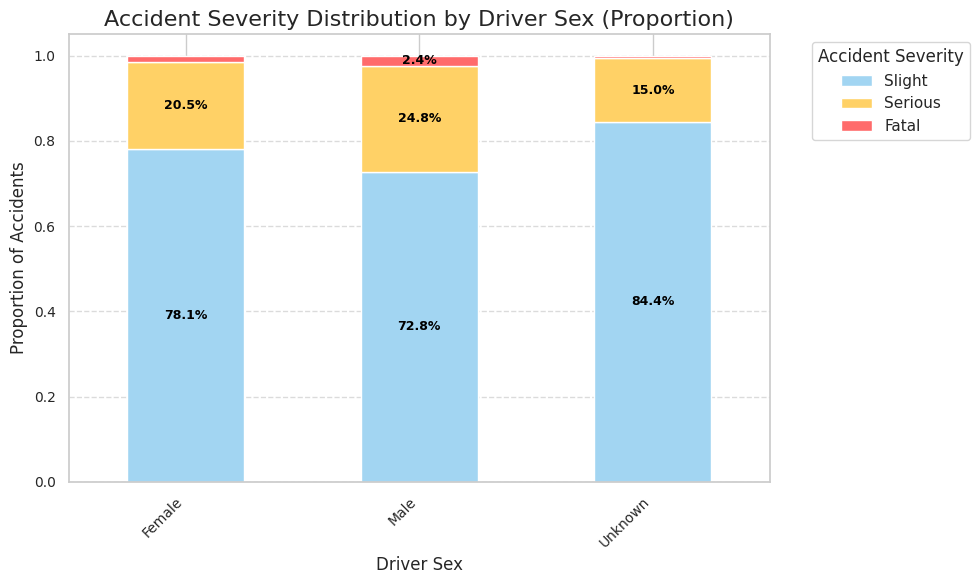

In [ ]:
# Define consistent severity colors
severity_colors_map = {'Slight': '#A2D5F2', 'Serious': '#FFD166', 'Fatal': '#FF6B6B'}

# Calculate the proportion of each accident severity for each driver sex
sex_severity_proportion = df_clean.groupby('driver_sex')['accident_severity'].value_counts(normalize=True).unstack(fill_value=0)

# Sort the columns (severity levels) for consistent stacking order
severity_order = ['Slight', 'Serious', 'Fatal']
sex_severity_proportion = sex_severity_proportion[severity_order]

# Plotting the stacked bar chart
ax = sex_severity_proportion.plot(kind='bar', stacked=True, figsize=(10, 6), color=[severity_colors_map[s] for s in severity_order])

plt.title('Accident Severity Distribution by Driver Sex (Proportion)', fontsize=16)
plt.xlabel('Driver Sex', fontsize=12)
plt.ylabel('Proportion of Accidents', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.legend(title='Accident Severity', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Annotate each segment with percentage
for bar_group in ax.containers:
    for bar in bar_group:
        height = bar.get_height()
        if height > 0.02:  # Only annotate if segment is large enough to display
            ax.annotate(f'{height*100:.1f}%',
                        xy=(bar.get_x() + bar.get_width() / 2, bar.get_y() + height / 2),
                        ha='center',
                        va='center',
                        fontsize=9,
                        fontweight='bold',
                        color='black')

plt.tight_layout()
plt.show()

From these numbers, we can observe that while males are involved in more accidents overall, they also have a higher proportion of serious and fatal accidents compared to females and 'Unknown' categories. Conversely, the 'Unknown' driver sex category shows the highest proportion of slight accidents and the lowest proportion of fatal accidents.

### Age of Driver

In [ ]:
print("--- Driver Age Distribution (Numerical Summary) ---")
print(df_clean['driver_age'].describe())

print("\n--- Casualty Age Distribution by Accident Severity (Numerical Summary) ---")
print(df_clean.groupby('accident_severity')['casualty_age'].describe())

--- Driver Age Distribution (Numerical Summary) ---
count    1.197405e+06
mean     3.600832e+01
std      2.066525e+01
min      0.000000e+00
25%      2.300000e+01
50%      3.500000e+01
75%      5.000000e+01
max      1.010000e+02
Name: driver_age, dtype: float64

--- Casualty Age Distribution by Accident Severity (Numerical Summary) ---
                      count       mean        std  min   25%   50%   75%  \
accident_severity                                                          
Fatal               23441.0  44.074570  21.756596  0.0  26.0  41.0  60.0   
Serious            270741.0  39.381161  20.183199  0.0  23.0  36.0  54.0   
Slight             903223.0  36.715714  18.639851  0.0  23.0  34.0  49.0   

                     max  
accident_severity         
Fatal               98.0  
Serious            101.0  
Slight             100.0  


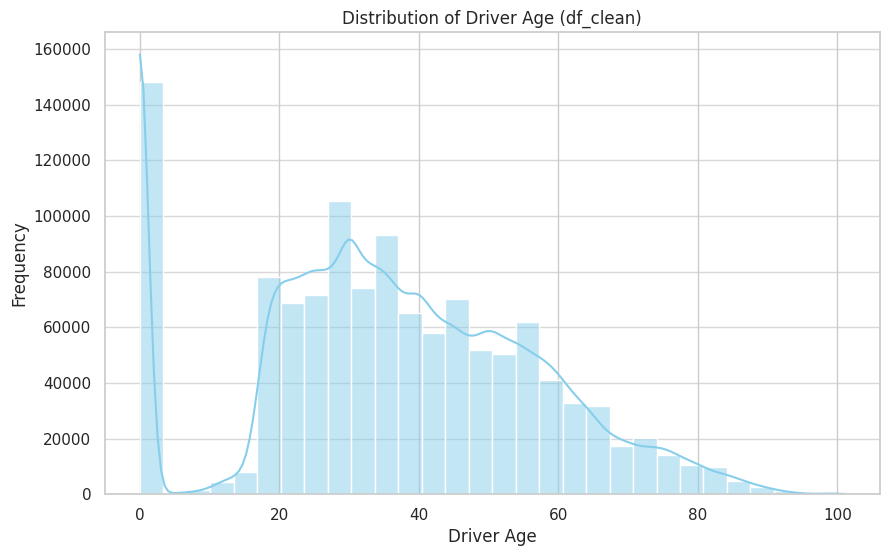

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df_clean['driver_age'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of Driver Age (df_clean)')
plt.xlabel('Driver Age')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

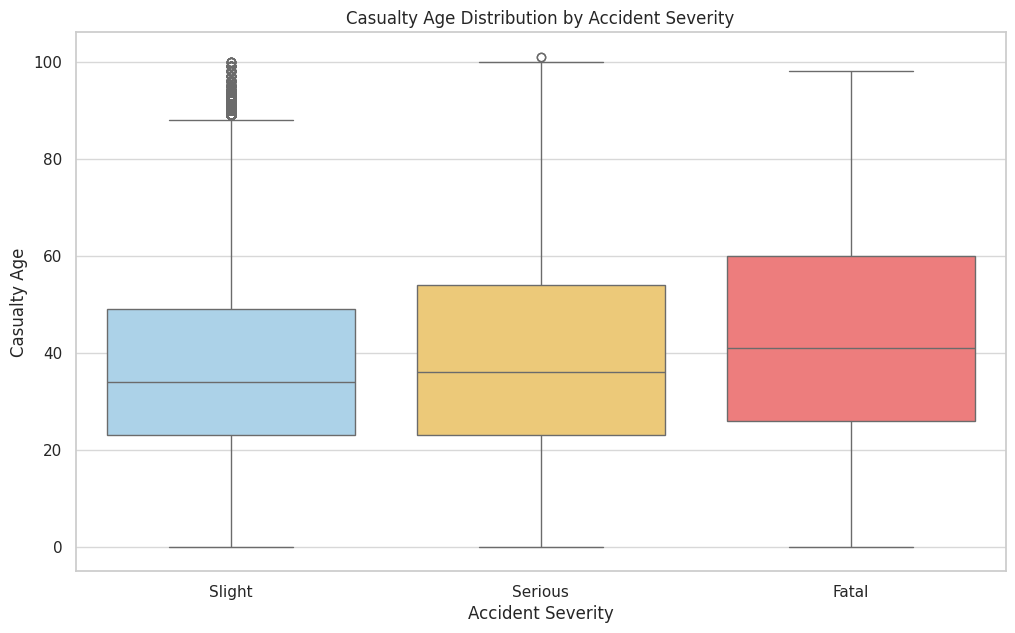

In [ ]:
severity_order = ['Slight', 'Serious', 'Fatal']

plt.figure(figsize=(12, 7))
sns.boxplot(data=df_clean, x='accident_severity', y='casualty_age',
            order=severity_order, hue='accident_severity', palette=severity_colors_map, legend=False)
plt.title('Casualty Age Distribution by Accident Severity')
plt.xlabel('Accident Severity')
plt.ylabel('Casualty Age')
plt.grid(axis='y', alpha=0.75)
plt.show()

The average driver in accidents is around 36 years old. Most drivers are between 23 to 50 years old.
Older people tend to be in more serious accidents. Fatal accidents involve people averaging 44 years old, serious ones around 39 years, and slight accidents around 37 years. Simply put, the older the person, the more severe the accident.
Most accidents in the data are slight, and very few are fatal, which is normal in real life

### Driver Distance Banding

In [ ]:
dist_col = 'driver_distance_banding'
total = len(df_clean)
dist_counts = df_clean[dist_col].value_counts()

print("--- Driver Commute Distance Distribution (Counts) ---")
print(dist_counts)

# Proportion table with severity
dist_sev = pd.crosstab(df_clean[dist_col], df_clean['accident_severity'], normalize='index')

# Ensure severity order for consistent stacking
severity_order = ['Slight', 'Serious', 'Fatal']
dist_sev = dist_sev[severity_order]

print("\n--- Commute Distance vs Accident Severity (Proportion) ---")
print(dist_sev)

--- Driver Commute Distance Distribution (Counts) ---
driver_distance_banding
Unknown                                                                 1004895
Collision occurred within 5km of drivers home postcode                    95681
Collision occurred between 5.001 and 10km of drivers home postcode        32430
Collision occurred between 20.001 and 100km of drivers home postcode      29246
Collision occurred between 10.001 and 20km of drivers home postcode       26878
Collision occurred over 100km of drivers home postcode                     8275
Name: count, dtype: int64

--- Commute Distance vs Accident Severity (Proportion) ---
accident_severity                                     Slight   Serious  \
driver_distance_banding                                                  
Collision occurred between 10.001 and 20km of d...  0.703698  0.269775   
Collision occurred between 20.001 and 100km of ...  0.680230  0.286774   
Collision occurred between 5.001 and 10km of dr...  0.720105

/tmp/ipykernel_2041/1193730503.py:25: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


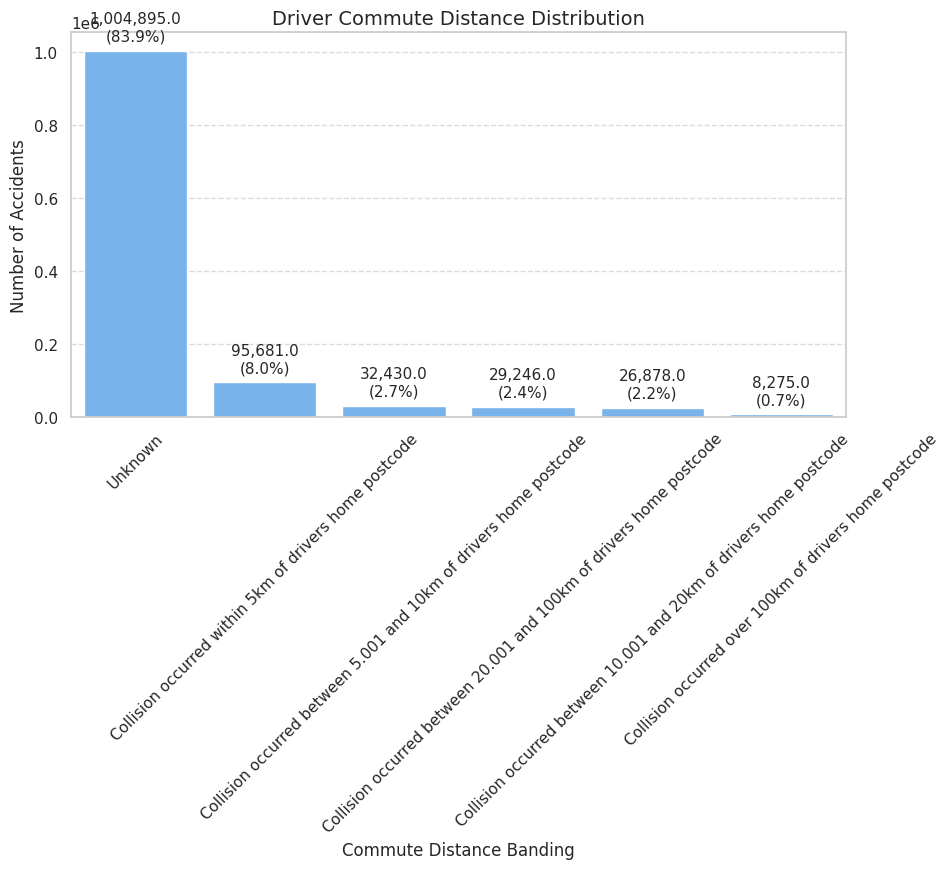

In [ ]:
dist_col = 'driver_distance_banding'
total = len(df_clean)
dist_counts = df_clean[dist_col].value_counts()

# Count plot with percentages
plt.figure(figsize=(10,5))
ax = sns.countplot(data=df_clean, x=dist_col, order=dist_counts.index, color='#66b3ff')
plt.title("Driver Commute Distance Distribution", fontsize=14)
plt.xlabel("Commute Distance Banding", fontsize=12)
plt.ylabel("Number of Accidents", fontsize=12)
plt.xticks(rotation=45, fontsize=11)
plt.yticks(fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Annotate
for p in ax.patches:
    height = p.get_height()
    percent = height / total * 100
    ax.annotate(f'{height:,}\n({percent:.1f}%)',
                xy=(p.get_x() + p.get_width()/2, height),
                xytext=(0,5),
                textcoords='offset points',
                ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.show()

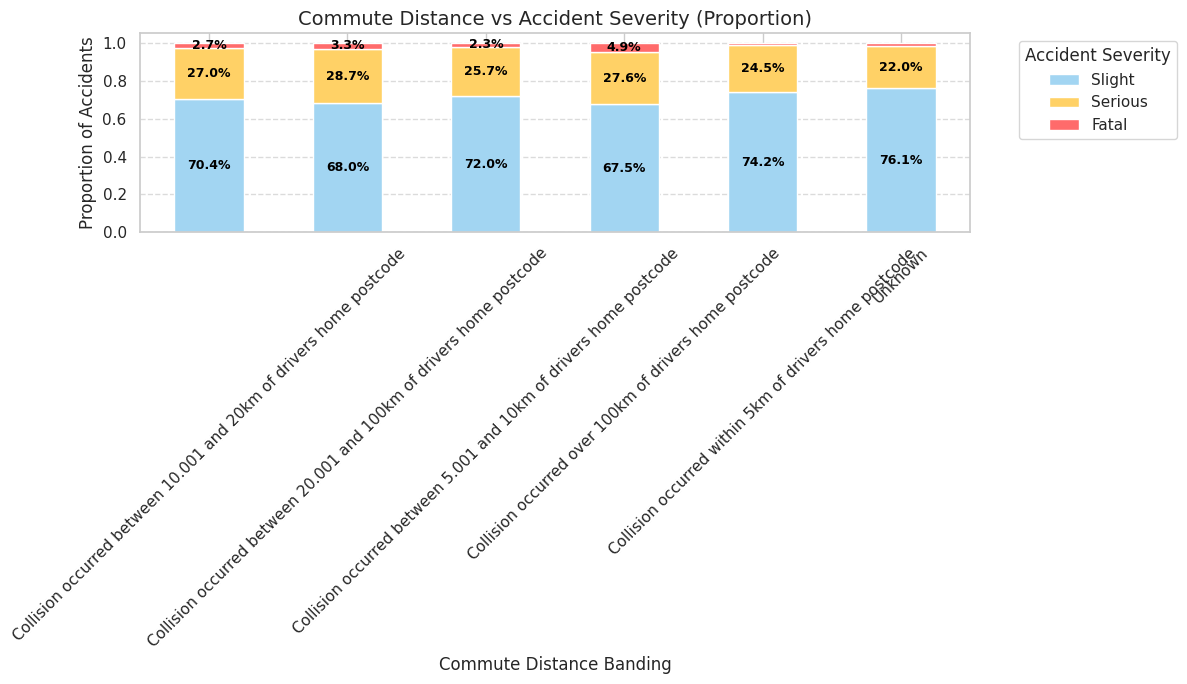

In [ ]:
# Proportion table with severity
dist_sev = pd.crosstab(df_clean[dist_col], df_clean['accident_severity'], normalize='index')

# Ensure severity order for consistent stacking
severity_order = ['Slight', 'Serious', 'Fatal']
dist_sev = dist_sev[severity_order]

# Create a figure and an axes object with a larger size
fig, ax = plt.subplots(figsize=(12, 7))

# Plotting the stacked bar chart, passing the ax object
dist_sev.plot(kind='bar', stacked=True, color=[severity_colors_map[s] for s in severity_order], ax=ax)

plt.title("Commute Distance vs Accident Severity (Proportion)", fontsize=14)
plt.xlabel("Commute Distance Banding", fontsize=12)
plt.ylabel("Proportion of Accidents", fontsize=12)
plt.xticks(rotation=45, fontsize=11)
plt.yticks(fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title="Accident Severity", fontsize=11, title_fontsize=12, bbox_to_anchor=(1.05, 1), loc='upper left')

# Annotate each segment with percentage
for bar_group in ax.containers:
    for bar in bar_group:
        height = bar.get_height()
        if height > 0.02:  # Only annotate if segment is large enough to display
            ax.annotate(f'{height*100:.1f}%',
                        xy=(bar.get_x() + bar.get_width() / 2, bar.get_y() + height / 2),
                        ha='center',
                        va='center',
                        fontsize=9,
                        fontweight='bold',
                        color='black')

plt.tight_layout()
plt.show()

Most accidents happen close to home, within 5km, which shows that people are more likely to have an accident in familiar areas. However, when it comes to how serious the accident is, longer distances are more dangerous. Drivers traveling over 100km have the highest chance of a fatal accident at 4.9%, while drivers within 5km have the lowest at just 1.3%. This likely happens because long-distance driving involves faster roads and highways. On the other hand, drivers near home mostly experience minor accidents. One thing to keep in mind is that most records have unknown distance, so these findings should be read with caution.

## Temporal Factors

### Hour of Day

In [ ]:
# 1 Bin hour into periods
def hour_bin(h):
    if 0 <= h < 6:
        return 'Night (0-5)'
    elif 6 <= h < 12:
        return 'Morning (6-11)'
    elif 12 <= h < 18:
        return 'Afternoon (12-17)'
    else:
        return 'Evening (18-23)'

df_clean['hour_bin'] = df_clean['hour'].apply(hour_bin)

# Counts
hour_counts = df_clean['hour_bin'].value_counts().sort_index()
print("Accidents by Hour Bin:")
print(hour_counts)

# Severity cross-tab
hour_sev = df_clean.groupby(['hour_bin','accident_severity']).size().reset_index(name='count')
hour_sev['within_prop'] = hour_sev.groupby('hour_bin')['count'].transform(lambda x: x / x.sum())
print("Accident Severity by Hour Bin:")
print(hour_sev)

Accidents by Hour Bin:
hour_bin
Afternoon (12-17)    534488
Evening (18-23)      293450
Morning (6-11)       308456
Night (0-5)           61011
Name: count, dtype: int64
Accident Severity by Hour Bin:
             hour_bin accident_severity   count  within_prop
0   Afternoon (12-17)             Fatal    9021     0.016878
1   Afternoon (12-17)           Serious  118404     0.221528
2   Afternoon (12-17)            Slight  407063     0.761594
3     Evening (18-23)             Fatal    6680     0.022764
4     Evening (18-23)           Serious   69442     0.236640
5     Evening (18-23)            Slight  217328     0.740596
6      Morning (6-11)             Fatal    5046     0.016359
7      Morning (6-11)           Serious   65923     0.213719
8      Morning (6-11)            Slight  237487     0.769922
9         Night (0-5)             Fatal    2694     0.044156
10        Night (0-5)           Serious   16972     0.278179
11        Night (0-5)            Slight   41345     0.677665


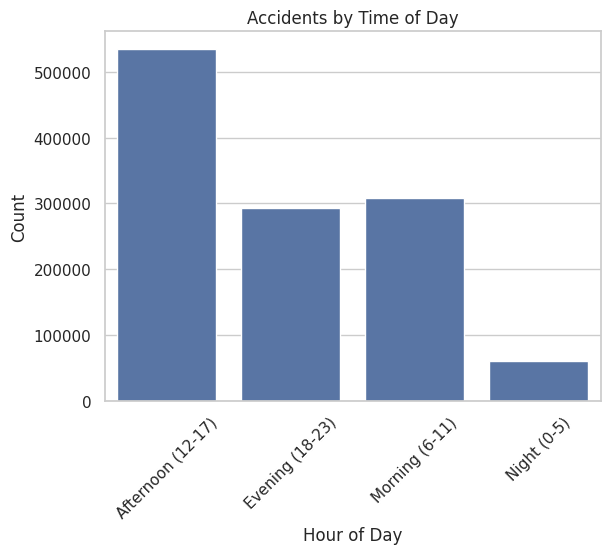

In [ ]:
# Count bar plot
sns.barplot(x=hour_counts.index, y=hour_counts.values)
plt.title("Accidents by Time of Day")
plt.ylabel("Count")
plt.xlabel("Hour of Day")
plt.xticks(rotation=45)
plt.show()

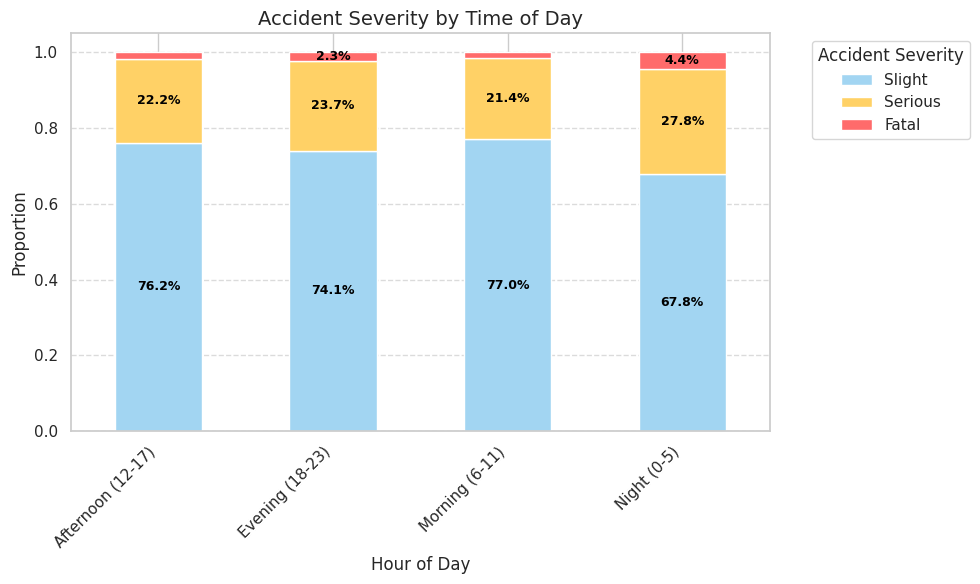

In [ ]:
# Stacked severity bar
# Ensure severity_colors_map is defined (it's already defined in previous cells but good practice to ensure context)
severity_colors_map = {'Slight': '#A2D5F2', 'Serious': '#FFD166', 'Fatal': '#FF6B6B'}

sev_pivot = hour_sev.pivot(index='hour_bin', columns='accident_severity', values='within_prop').fillna(0)

# Ensure the columns are in the desired order for stacking
severity_order = ['Slight', 'Serious', 'Fatal']
sev_pivot = sev_pivot[severity_order]

# Create a figure and an axes object for better control over layout
fig, ax = plt.subplots(figsize=(10, 6))

sev_pivot.plot(kind='bar', stacked=True, color=[severity_colors_map[s] for s in severity_order], ax=ax)
plt.title("Accident Severity by Time of Day", fontsize=14)
plt.ylabel("Proportion", fontsize=12)
plt.xlabel("Hour of Day", fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Accident Severity', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=11, title_fontsize=12)

# Annotate each segment with percentage
for bar_group in ax.containers:
    for bar in bar_group:
        height = bar.get_height()
        if height > 0.02:  # Only annotate if segment is large enough to display
            ax.annotate(f'{height*100:.1f}%',
                        xy=(bar.get_x() + bar.get_width() / 2, bar.get_y() + height / 2),
                        ha='center',
                        va='center',
                        fontsize=9,
                        fontweight='bold',
                        color='black')

plt.tight_layout() # Adjust layout to prevent overlap
plt.show()

Most accidents happen in the afternoon, but they are mostly minor. Night time has the fewest accidents but is the most dangerous, with the highest fatal rate of 4.4%. This is likely due to poor visibility and fatigue. Morning is the safest time with mostly slight accidents. So simply, more accidents during the day, but more deadly at night.

### Day of Week

In [ ]:
# Counts
# Step 1: Map abbreviations to full day names
abbr_to_full = {
    'Mon':'Monday',
    'Tue':'Tuesday',
    'Wed':'Wednesday',
    'Thu':'Thursday',
    'Fri':'Friday',
    'Sat':'Saturday',
    'Sun':'Sunday'
}

df_clean['day_of_week_full'] = df_clean['day_of_week'].map(abbr_to_full)
day_counts = df_clean['day_of_week_full'].value_counts().reindex(['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])
print("Accidents by Day of Week:")
print(day_counts)

# Severity cross-tab
day_sev = df_clean.groupby(['day_of_week_full','accident_severity']).size().reset_index(name='count')
day_sev['within_prop'] = day_sev.groupby('day_of_week_full')['count'].transform(lambda x: x / x.sum())
print("Accident Severity by Day of Week:")
print(day_sev)


Accidents by Day of Week:
day_of_week_full
Monday       163845
Tuesday      170175
Wednesday    174686
Thursday     178040
Friday       199920
Saturday     170158
Sunday       140581
Name: count, dtype: int64
Accident Severity by Day of Week:
   day_of_week_full accident_severity   count  within_prop
0            Friday             Fatal    3729     0.018652
1            Friday           Serious   44954     0.224860
2            Friday            Slight  151237     0.756488
3            Monday             Fatal    3217     0.019634
4            Monday           Serious   35677     0.217748
5            Monday            Slight  124951     0.762617
6          Saturday             Fatal    3791     0.022279
7          Saturday           Serious   41670     0.244890
8          Saturday            Slight  124697     0.732831
9            Sunday             Fatal    3671     0.026113
10           Sunday           Serious   35844     0.254970
11           Sunday            Slight  101066    

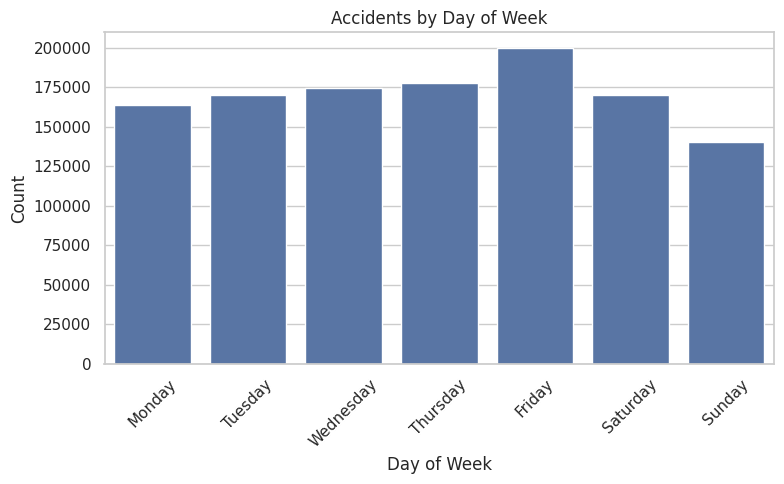

In [ ]:


# Step 2: Define correct order
days_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

# Step 3: Count and reindex
day_counts = df_clean['day_of_week_full'].value_counts().reindex(days_order, fill_value=0)

# Step 4: Plot
plt.figure(figsize=(8,5))
sns.barplot(x=day_counts.index, y=day_counts.values)
plt.title("Accidents by Day of Week")
plt.ylabel("Count")
plt.xlabel("Day of Week")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

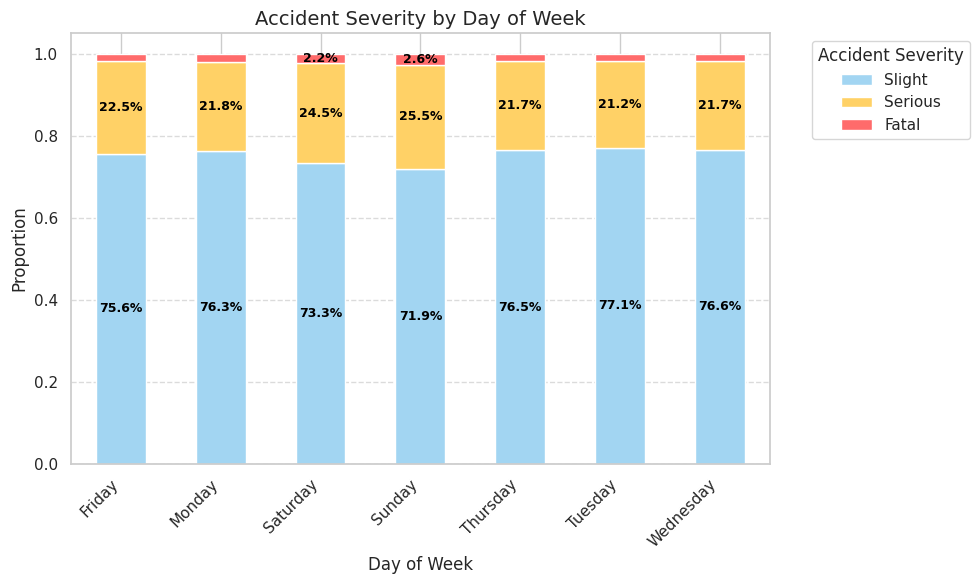

In [ ]:
# Pivot for stacked bar
sev_pivot = day_sev.pivot(index='day_of_week_full', columns='accident_severity', values='within_prop').fillna(0)

# Ensure the columns are in the desired order for stacking
severity_order = ['Slight', 'Serious', 'Fatal']
sev_pivot = sev_pivot[severity_order]

# Create a figure and an axes object for better control over layout
fig, ax = plt.subplots(figsize=(10, 6))

# Plot stacked bar, passing the ax object
sev_pivot.plot(kind='bar', stacked=True, color=[severity_colors_map[s] for s in severity_order], ax=ax)

plt.title("Accident Severity by Day of Week", fontsize=14)
plt.ylabel("Proportion", fontsize=12)
plt.xlabel("Day of Week", fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Accident Severity', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=11, title_fontsize=12)

# Annotate each segment with percentage
for bar_group in ax.containers:
    for bar in bar_group:
        height = bar.get_height()
        if height > 0.02:  # Only annotate if segment is large enough to display
            ax.annotate(f'{height*100:.1f}%',
                        xy=(bar.get_x() + bar.get_width() / 2, bar.get_y() + height / 2),
                        ha='center',
                        va='center',
                        fontsize=9,
                        fontweight='bold',
                        color='black')

plt.tight_layout() # Adjust layout to prevent overlap
plt.show()

Friday has the most accidents as people rush home after the week. However, weekends are more dangerous Sunday has the highest fatal rate at 2.6%, likely due to late night driving and alcohol. Tuesday is the safest day with the lowest fatal rate of just 1.6%. So more accidents happen on weekdays, but weekend accidents tend to be more deadly.

### Month

In [ ]:
# Create mapping from abbreviations to full month names
abbr_to_full_month = {
    'Jan':'January',
    'Feb':'February',
    'Mar':'March',
    'Apr':'April',
    'May':'May',
    'Jun':'June',
    'Jul':'July',
    'Aug':'August',
    'Sep':'September',
    'Oct':'October',
    'Nov':'November',
    'Dec':'December'
}

df_clean['month_full'] = df_clean['month'].map(abbr_to_full_month)
months_order = ['January','February','March','April','May','June','July','August','September','October','November','December']

month_counts = df_clean['month_full'].value_counts().reindex(months_order, fill_value=0)
print("Accidents by Month:")
print(month_counts)
# Group by month and severity
month_sev = df_clean.groupby(['month_full','accident_severity']).size().reset_index(name='count')

# Within-month proportions
month_sev['within_prop'] = month_sev.groupby('month_full')['count'].transform(lambda x: x / x.sum())

# Sort by month order for plotting
month_sev['month_full'] = pd.Categorical(month_sev['month_full'], categories=months_order, ordered=True)
month_sev = month_sev.sort_values('month_full')

print("Accident Severity by Month:")
print(month_sev)

Accidents by Month:
month_full
January       96146
February      86182
March         90142
April         83884
May          100332
June         106986
July         108601
August       107014
September    108412
October      107902
November     105320
December      96484
Name: count, dtype: int64
Accident Severity by Month:
   month_full accident_severity  count  within_prop
14    January            Slight  74291     0.772689
13    January           Serious  19966     0.207663
12    January             Fatal   1889     0.019647
11   February            Slight  66392     0.770370
10   February           Serious  18103     0.210055
9    February             Fatal   1687     0.019575
21      March             Fatal   1721     0.019092
23      March            Slight  69150     0.767123
22      March           Serious  19271     0.213785
0       April             Fatal   1604     0.019122
2       April            Slight  62874     0.749535
1       April           Serious  19406     0.231343

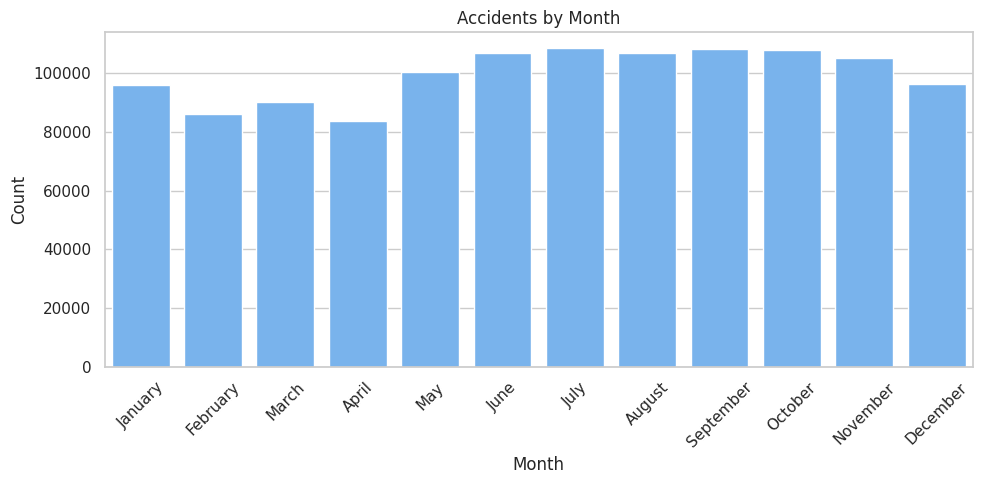

In [ ]:
# Calendar order
months_order = ['January','February','March','April','May','June','July','August','September','October','November','December']

# Count accidents by month
month_counts = df_clean['month_full'].value_counts().reindex(months_order, fill_value=0)

# Plot
plt.figure(figsize=(10,5))
sns.barplot(x=month_counts.index, y=month_counts.values, color='#66b3ff')  # blue for counts
plt.title("Accidents by Month")
plt.ylabel("Count")
plt.xlabel("Month")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

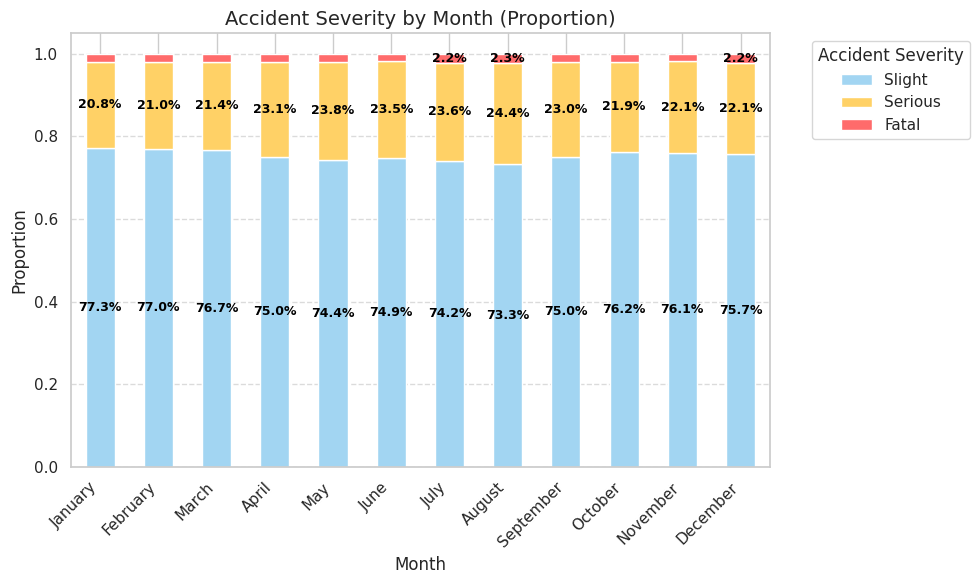

In [ ]:
# Create mapping from abbreviations to full month names (if not already done)
abbr_to_full_month = {
    'Jan':'January',
    'Feb':'February',
    'Mar':'March',
    'Apr':'April',
    'May':'May',
    'Jun':'June',
    'Jul':'July',
    'Aug':'August',
    'Sep':'September',
    'Oct':'October',
    'Nov':'November',
    'Dec':'December'
}

df_clean['month_full'] = df_clean['month'].map(abbr_to_full_month)
months_order = ['January','February','March','April','May','June','July','August','September','October','November','December']

# Group by month and severity
month_sev = df_clean.groupby(['month_full','accident_severity']).size().reset_index(name='count')

# Calculate within-month proportions
month_sev['within_prop'] = month_sev.groupby('month_full')['count'].transform(lambda x: x / x.sum())

# Sort by month order for plotting
month_sev['month_full'] = pd.Categorical(month_sev['month_full'], categories=months_order, ordered=True)
month_sev = month_sev.sort_values('month_full')

# Pivot for stacked bar
sev_pivot = month_sev.pivot(index='month_full', columns='accident_severity', values='within_prop').fillna(0)

# Ensure severity order for consistent stacking
severity_order = ['Slight', 'Serious', 'Fatal']
sev_pivot = sev_pivot[severity_order]

# Define consistent severity colors (if not already defined)
severity_colors_map = {'Slight': '#A2D5F2', 'Serious': '#FFD166', 'Fatal': '#FF6B6B'}

# Create a figure and an axes object for better control over layout
fig, ax = plt.subplots(figsize=(10, 6))

# Plot stacked bar, passing the ax object
sev_pivot.plot(kind='bar', stacked=True, color=[severity_colors_map[s] for s in severity_order], ax=ax)

plt.title("Accident Severity by Month (Proportion)", fontsize=14)
plt.ylabel("Proportion", fontsize=12)
plt.xlabel("Month", fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Accident Severity', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=11, title_fontsize=12)

# Annotate each segment with percentage
for bar_group in ax.containers:
    for bar in bar_group:
        height = bar.get_height()
        if height > 0.02:  # Only annotate if segment is large enough to display
            ax.annotate(f'{height*100:.1f}%',
                        xy=(bar.get_x() + bar.get_width() / 2, bar.get_y() + height / 2),
                        ha='center',
                        va='center',
                        fontsize=9,
                        fontweight='bold',
                        color='black')

plt.tight_layout() # Adjust layout to prevent overlap
plt.show()

Summer months like July, August, and September have the most accidents, likely because more people are traveling and roads are busier. January and February have the fewest accidents.
When it comes to severity, July, August, and December have slightly higher fatal rates around 2.2%, while November and June are the safest months with the lowest fatal rates. Winter months like December may see more deadly accidents due to poor weather and dark evenings.

### Season

In [ ]:
# Counts
season_counts = df_clean['season'].value_counts()
print("Accidents by Season:")
print(season_counts)

season_sev = df_clean.groupby(['season','accident_severity']).size().reset_index(name='count')
season_sev['within_prop'] = season_sev.groupby('season')['count'].transform(lambda x: x / x.sum())
print("Accident Severity by Season:")
print(season_sev)

Accidents by Season:
season
Summer    322601
Autumn    321634
Winter    278812
Spring    274358
Name: count, dtype: int64
Accident Severity by Season:
    season accident_severity   count  within_prop
0   Autumn             Fatal    5969     0.018558
1   Autumn           Serious   71914     0.223590
2   Autumn            Slight  243751     0.757852
3   Spring             Fatal    5166     0.018829
4   Spring           Serious   62528     0.227907
5   Spring            Slight  206664     0.753264
6   Summer             Fatal    6592     0.020434
7   Summer           Serious   76887     0.238335
8   Summer            Slight  239122     0.741231
9   Winter             Fatal    5714     0.020494
10  Winter           Serious   59412     0.213090
11  Winter            Slight  213686     0.766416


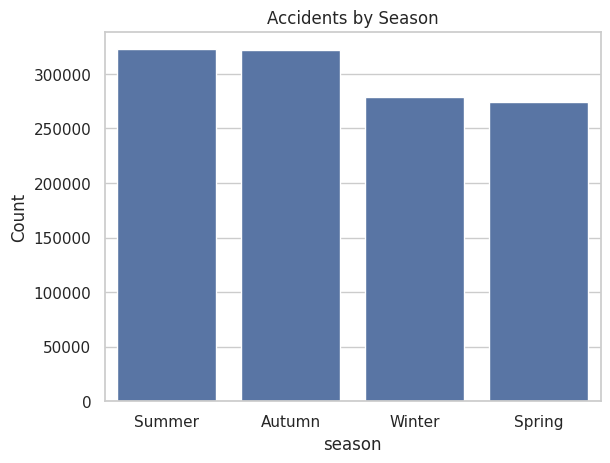

In [ ]:
# Plots
sns.barplot(x=season_counts.index, y=season_counts.values)
plt.title("Accidents by Season")
plt.ylabel("Count")
plt.show()

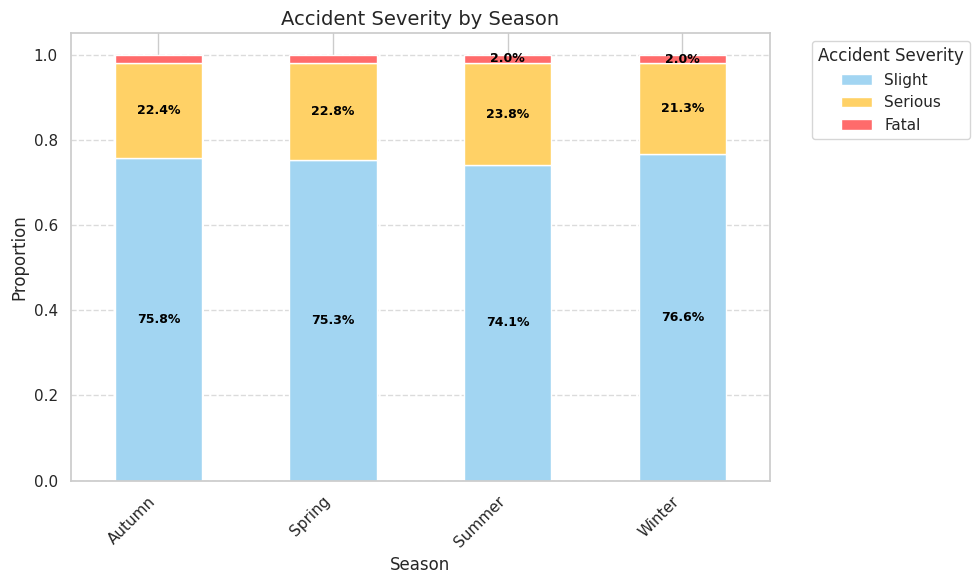

In [ ]:
sev_pivot = season_sev.pivot(index='season', columns='accident_severity', values='within_prop').fillna(0)

# Ensure severity order for consistent stacking
severity_order = ['Slight', 'Serious', 'Fatal']
sev_pivot = sev_pivot[severity_order]

# Create a figure and an axes object for better control over layout
fig, ax = plt.subplots(figsize=(10, 6))

sev_pivot.plot(kind='bar', stacked=True,
              color=[severity_colors_map[s] for s in severity_order],
              ax=ax)

plt.title("Accident Severity by Season", fontsize=14)
plt.ylabel("Proportion", fontsize=12)
plt.xlabel("Season", fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Accident Severity', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=11, title_fontsize=12)

# Annotate each segment with percentage
for bar_group in ax.containers:
    for bar in bar_group:
        height = bar.get_height()
        if height > 0.02:  # Only annotate if segment is large enough to display
            ax.annotate(f'{height*100:.1f}%',
                        xy=(bar.get_x() + bar.get_width() / 2, bar.get_y() + height / 2),
                        ha='center',
                        va='center',
                        fontsize=9,
                        fontweight='bold',
                        color='black')

plt.tight_layout()
plt.show()

Summer and Autumn have the most accidents, likely due to more people traveling and being on the road. Winter and Spring have slightly fewer accidents.
When it comes to severity, Summer and Winter both have the highest fatal rates at around 2%. Summer likely due to more traffic and risky driving, while Winter is dangerous because of wet roads and poor visibility. Spring is the safest season with the lowest fatal rate.

### Year

In [ ]:
year_counts = df_clean['accident_year'].value_counts().sort_index()
year_sev = df_clean.groupby(['accident_year','accident_severity']).size().reset_index(name='count')
year_sev['within_prop'] = year_sev.groupby('accident_year')['count'].transform(lambda x: x / x.sum())
print("Accidents by Year:")
print(year_counts)
print("Accident Severity by Year:")
print(year_sev)


Accidents by Year:
accident_year
2020    216106
2021    241642
2022    252930
2023    247612
2024    239115
Name: count, dtype: int64
Accident Severity by Year:
    accident_year accident_severity   count  within_prop
0            2020             Fatal    4149     0.019199
1            2020           Serious   43830     0.202817
2            2020            Slight  168127     0.777984
3            2021             Fatal    4523     0.018718
4            2021           Serious   51917     0.214851
5            2021            Slight  185202     0.766431
6            2022             Fatal    4967     0.019638
7            2022           Serious   58093     0.229680
8            2022            Slight  189870     0.750682
9            2023             Fatal    4941     0.019955
10           2023           Serious   58042     0.234407
11           2023            Slight  184629     0.745638
12           2024             Fatal    4861     0.020329
13           2024           Serious   588

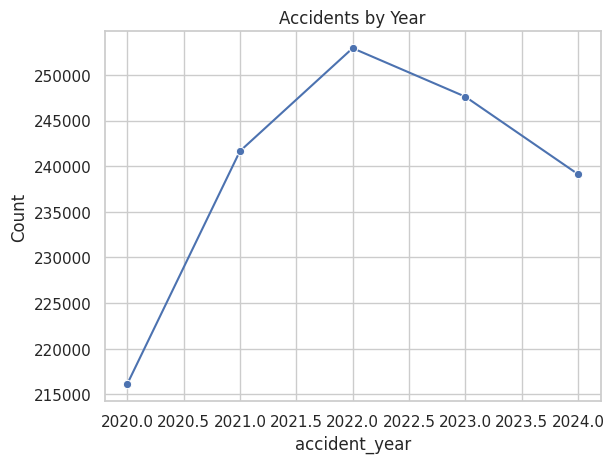

In [ ]:
# Plots
sns.lineplot(x=year_counts.index, y=year_counts.values, marker='o')
plt.title("Accidents by Year")
plt.ylabel("Count")
plt.show()


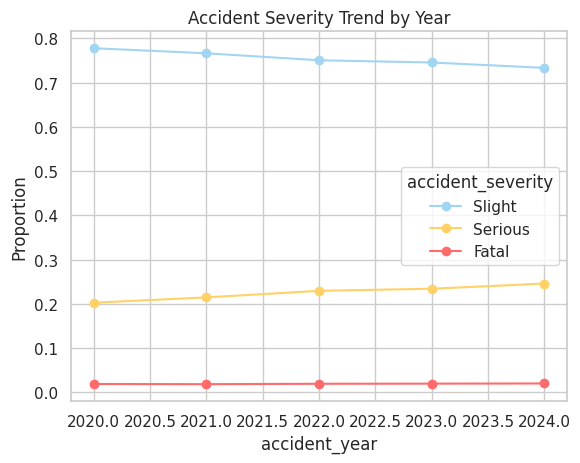

In [ ]:
sev_pivot = year_sev.pivot(index='accident_year', columns='accident_severity', values='within_prop').fillna(0)
sev_pivot[['Slight','Serious','Fatal']].plot(kind='line', marker='o', color=[severity_colors_map[s] for s in ['Slight','Serious','Fatal']])
plt.title("Accident Severity Trend by Year")
plt.ylabel("Proportion")
plt.show()

Accidents increased from 2020 to 2022, peaking at 252,930 in 2022, and then slightly declined in 2023 and 2024. The lower numbers in 2020 are likely due to COVID-19 lockdowns with fewer people on the road.
When it comes to severity, serious and fatal accidents have gradually increased over the years. In 2020, serious accidents were at 20%, but by 2024 they rose to 24.6%. This suggests that while total accidents may be stabilizing, the injuries are getting more severe over time.

### Risk Factors

In [ ]:
risk_factors = ['road_type','speed_limit','urban_or_rural_area',
                'weather_conditions','light_conditions','road_surface_conditions',
                'junction_control','towing_and_articulation']

# Convert to string/factor type and fill missing
for col in risk_factors:
    df_clean[col] = df_clean[col].astype(str).fillna('Unknown')

### Road Type

In [ ]:
# Overall counts
road_counts = df_clean['road_type'].value_counts()
print("Counts by road_type:")
print(road_counts)

# Cross-tab with severity
road_sev = df_clean.groupby(['road_type','accident_severity']).size().reset_index(name='count')
road_sev['within_prop'] = road_sev.groupby('road_type')['count'].transform(lambda x: x / x.sum())
print("\nAccident severity by road_type:")
print(road_sev)

Counts by road_type:
road_type
Single carriageway    847898
Dual carriageway      213593
Roundabout             67571
Unknown                25162
Slip road              22334
One way street         20847
Name: count, dtype: int64

Accident severity by road_type:
             road_type accident_severity   count  within_prop
0     Dual carriageway             Fatal    5233     0.024500
1     Dual carriageway           Serious   45526     0.213144
2     Dual carriageway            Slight  162834     0.762356
3       One way street             Fatal      75     0.003598
4       One way street           Serious    3229     0.154890
5       One way street            Slight   17543     0.841512
6           Roundabout             Fatal     316     0.004677
7           Roundabout           Serious   10428     0.154327
8           Roundabout            Slight   56827     0.840997
9   Single carriageway             Fatal   17467     0.020600
10  Single carriageway           Serious  205864     0

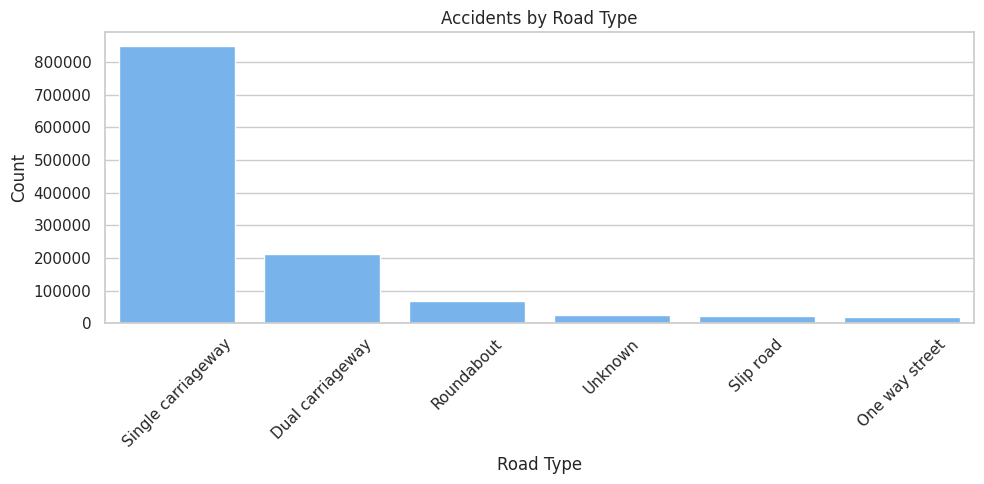

In [ ]:
# Count plot
plt.figure(figsize=(10,5))
sns.barplot(x=road_counts.index, y=road_counts.values, color='#66b3ff')
plt.title("Accidents by Road Type")
plt.ylabel("Count")
plt.xlabel("Road Type")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

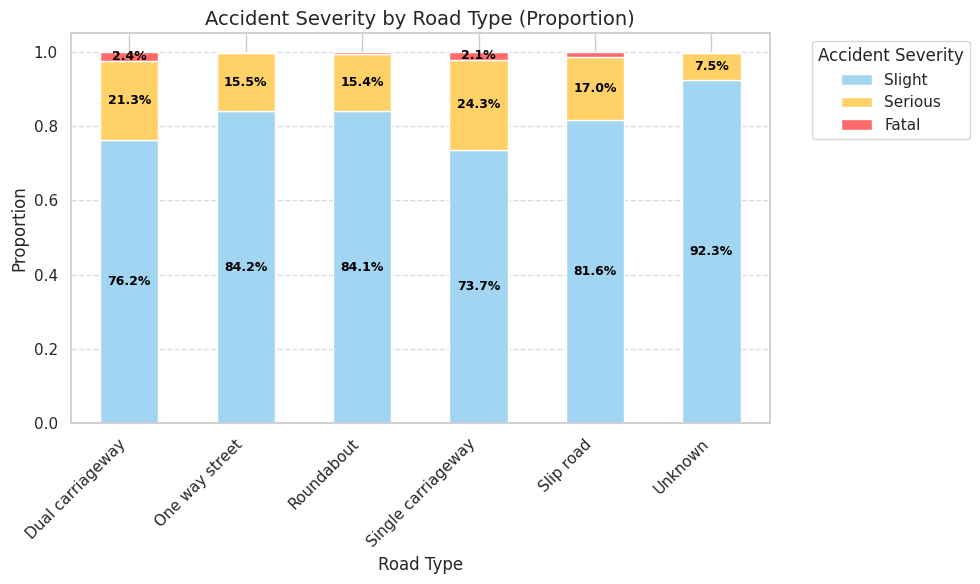

In [ ]:
# Stacked proportion plot
sev_pivot = road_sev.pivot(index='road_type', columns='accident_severity', values='within_prop').fillna(0)

# Ensure the columns are in the desired order for stacking
severity_order = ['Slight', 'Serious', 'Fatal']
sev_pivot = sev_pivot[severity_order]

# Create a figure and an axes object for better control over layout
fig, ax = plt.subplots(figsize=(10, 6))

sev_pivot.plot(kind='bar', stacked=True,
                                             color=[severity_colors_map[s] for s in severity_order],
                                             ax=ax)
plt.title("Accident Severity by Road Type (Proportion)", fontsize=14)
plt.ylabel("Proportion", fontsize=12)
plt.xlabel("Road Type", fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Accident Severity', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=11, title_fontsize=12)

# Annotate each segment with percentage
for bar_group in ax.containers:
    for bar in bar_group:
        height = bar.get_height()
        if height > 0.02:  # Only annotate if segment is large enough to display
            ax.annotate(f'{height*100:.1f}%',
                        xy=(bar.get_x() + bar.get_width() / 2, bar.get_y() + height / 2),
                        ha='center',
                        va='center',
                        fontsize=9,
                        fontweight='bold',
                        color='black')

plt.tight_layout()
plt.show()

Most accidents happen on single carriageways simply because they are the most common roads. However, when it comes to how dangerous they are, dual carriageways have the highest fatal rate at 2.4%, which makes sense as cars travel much faster on these roads. Single carriageways also contribute greatly to fatal accidents just because of their sheer volume. Roundabouts and one way streets are the safest road types with very low fatal rates, as traffic moves slower on these roads.In Simple wording a person can die  more likely to have an accident on a single carriageway, but more likely to die on a dual carriageway.

###  Speed Limit

In [ ]:
# Overall counts
speed_counts = df_clean['speed_limit'].value_counts()
print("Counts by Speed Limit:")
print(speed_counts)

# Cross-tab with severity
speed_sev = df_clean.groupby(['speed_limit','accident_severity']).size().reset_index(name='count')
speed_sev['within_prop'] = speed_sev.groupby('speed_limit')['count'].transform(lambda x: x / x.sum())
print("\nAccident severity by Speed Limit:")
print(speed_sev)


Counts by Speed Limit:
speed_limit
30         597465
60         168144
20         154888
40         117558
70          93419
50          65914
Unknown        17
Name: count, dtype: int64

Accident severity by Speed Limit:
   speed_limit accident_severity   count  within_prop
0           20             Fatal     694     0.004481
1           20           Serious   26756     0.172744
2           20            Slight  127438     0.822775
3           30             Fatal    5615     0.009398
4           30           Serious  121344     0.203098
5           30            Slight  470506     0.787504
6           40             Fatal    2254     0.019174
7           40           Serious   28494     0.242382
8           40            Slight   86810     0.738444
9           50             Fatal    2258     0.034257
10          50           Serious   17327     0.262873
11          50            Slight   46329     0.702870
12          60             Fatal    8936     0.053145
13          60        

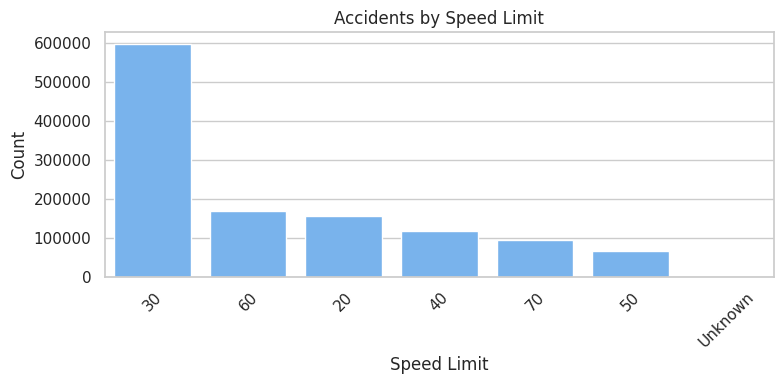

In [ ]:
# Plot counts
plt.figure(figsize=(8,4))
sns.barplot(x=speed_counts.index, y=speed_counts.values, color='#66b3ff')
plt.title("Accidents by Speed Limit")
plt.ylabel("Count")
plt.xlabel("Speed Limit")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


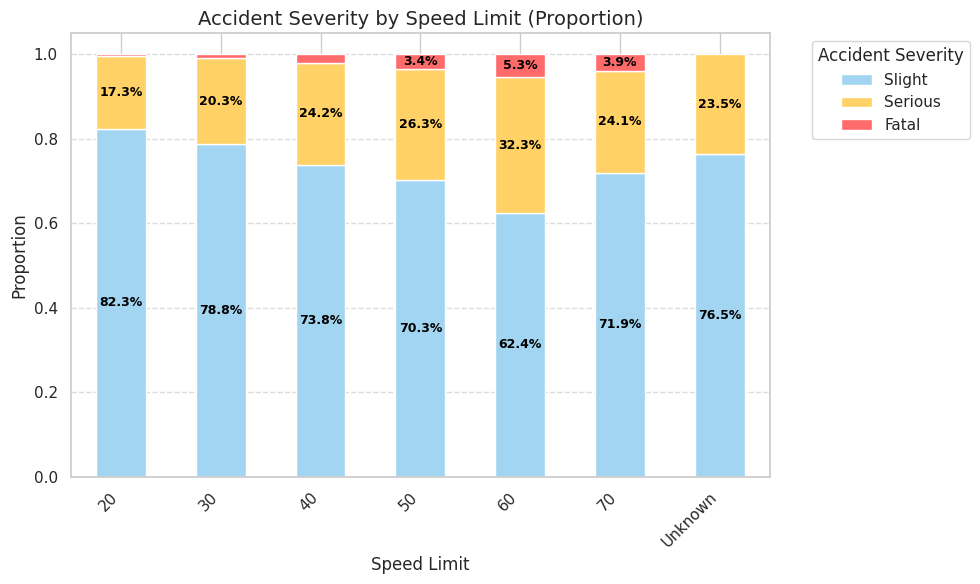

In [ ]:
# Stacked proportion plot
pivot = speed_sev.pivot(index='speed_limit', columns='accident_severity', values='within_prop').fillna(0)

# Ensure the columns are in the desired order for stacking
severity_order = ['Slight', 'Serious', 'Fatal']
pivot = pivot[severity_order]

# Create a figure and an axes object for better control over layout
fig, ax = plt.subplots(figsize=(10, 6))

pivot.plot(kind='bar', stacked=True,
                                         color=[severity_colors_map[s] for s in severity_order],
                                         ax=ax)
plt.title("Accident Severity by Speed Limit (Proportion)", fontsize=14)
plt.ylabel("Proportion", fontsize=12)
plt.xlabel("Speed Limit", fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Accident Severity', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=11, title_fontsize=12)

# Annotate each segment with percentage
for bar_group in ax.containers:
    for bar in bar_group:
        height = bar.get_height()
        if height > 0.02:  # Only annotate if segment is large enough to display
            ax.annotate(f'{height*100:.1f}%',
                        xy=(bar.get_x() + bar.get_width() / 2, bar.get_y() + height / 2),
                        ha='center',
                        va='center',
                        fontsize=9,
                        fontweight='bold',
                        color='black')

plt.tight_layout()
plt.show()

Most accidents happen in 30mph zones because these are busy city roads with lots of traffic, but most of these accidents are minor. As speed limits increase, accidents become more deadly. Roads with a 60mph limit have the highest fatal rate at 5.3%, while 20mph zones are the safest with only 0.4% fatal rate. This clearly shows that higher speed means more dangerous accidents. Simply put, slow roads have more accidents but fast roads have more deaths.

### Towing and Articulation

In [ ]:
# 2.1 Counts & Proportions
t_counts = df_clean['towing_and_articulation'].value_counts().head(7).reset_index()
t_counts.columns = ['towing_and_articulation','count']
t_counts['prop'] = t_counts['count']/t_counts['count'].sum()
print("Towing & Articulation Distribution:")
print(t_counts)

# 2.2 Severity Cross-tab
t_sev = df_clean.groupby(['towing_and_articulation','accident_severity']).size().reset_index(name='n')
t_sev['within_prop'] = t_sev.groupby('towing_and_articulation')['n'].transform(lambda x: x / x.sum())
print("Towing & Articulation vs Accident Severity:")
print(t_sev)

Towing & Articulation Distribution:
      towing_and_articulation    count      prop
0         No tow/articulation  1150067  0.960466
1                     Unknown    31337  0.026171
2         Articulated vehicle     8890  0.007424
3              Single trailer     4300  0.003591
4                   Other tow     1675  0.001399
5                     Caravan      947  0.000791
6  Double or multiple trailer      189  0.000158
Towing & Articulation vs Accident Severity:
       towing_and_articulation accident_severity       n  within_prop
0          Articulated vehicle             Fatal     789     0.088751
1          Articulated vehicle           Serious    2182     0.245444
2          Articulated vehicle            Slight    5919     0.665804
3                      Caravan             Fatal      27     0.028511
4                      Caravan           Serious     221     0.233369
5                      Caravan            Slight     699     0.738120
6   Double or multiple trailer        

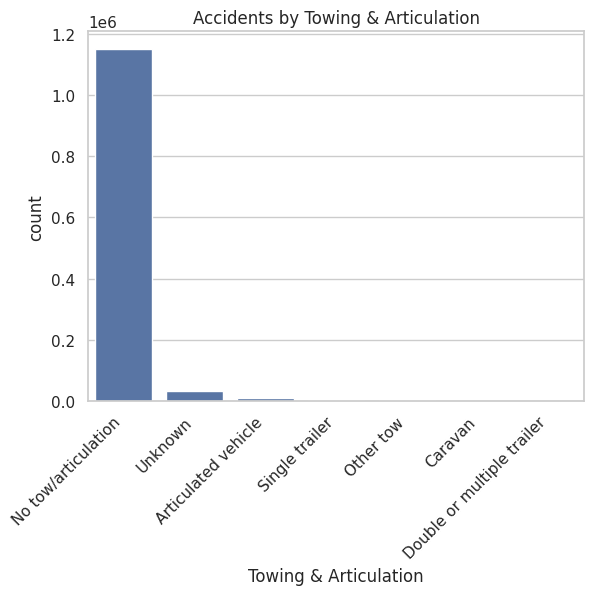

In [ ]:
# 2.3 Plots
sns.barplot(data=t_counts, x='towing_and_articulation', y='count', order=t_counts['towing_and_articulation'])
plt.title("Accidents by Towing & Articulation")
plt.xlabel("Towing & Articulation") # Changed x-axis label
plt.xticks(rotation=45, ha='right')
plt.show()

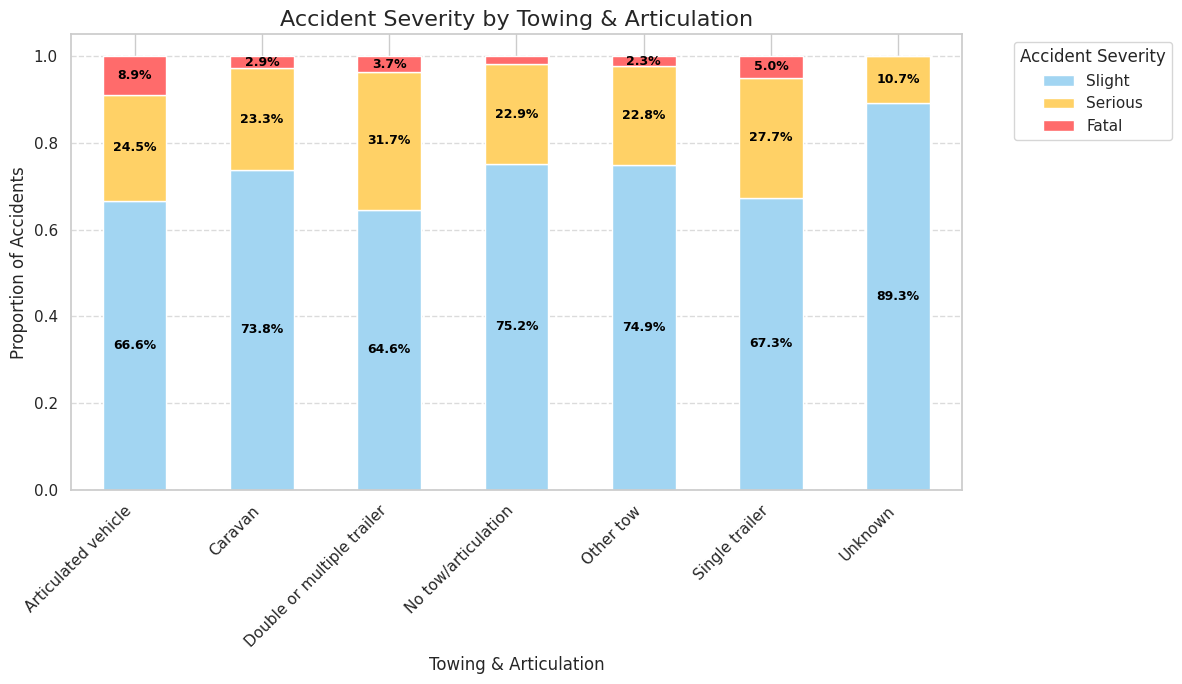

In [ ]:
sev_data = t_sev.pivot(index='towing_and_articulation', columns='accident_severity', values='within_prop').fillna(0)
sev_data = sev_data[severity_order]

# Create a figure and an axes object to control plot size and legend placement
fig, ax = plt.subplots(figsize=(12, 7))

sev_data.plot(kind='bar', stacked=True, color=[severity_colors_map[s] for s in severity_order], ax=ax)
plt.title("Accident Severity by Towing & Articulation", fontsize=16)
plt.xlabel("Towing & Articulation", fontsize=12)
plt.ylabel("Proportion of Accidents", fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Accident Severity', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=11, title_fontsize=12)

# Annotate each segment with percentage
for bar_group in ax.containers:
    for bar in bar_group:
        height = bar.get_height()
        if height > 0.02:  # Only annotate if segment is large enough to display
            ax.annotate(f'{height*100:.1f}%',
                        xy=(bar.get_x() + bar.get_width() / 2, bar.get_y() + height / 2),
                        ha='center',
                        va='center',
                        fontsize=9,
                        fontweight='bold',
                        color='black')

plt.tight_layout()
plt.show()

Most vehicles involved in accidents have no towing at all, making up 96% of all cases, which is expected as most cars on the road are standard vehicles.
However, when it comes to severity, articulated vehicles like lorries and heavy trucks are by far the most dangerous, with a shocking fatal rate of 8.9%. Single trailers also have a high fatal rate of 4.9%. This makes sense as these are large and heavy vehicles that are harder to control and cause much more damage in a crash.
Regular vehicles with no towing have a much lower fatal rate of just 1.9%. In simple words, heavy towing vehicles are rare on the road but cause the most deadly accidents when they crash.

### Weather Conditions

In [ ]:
# Counts
weather_counts = df_clean['weather_conditions'].value_counts()
print("Counts by Weather Conditions:")
print(weather_counts)

# Cross-tab
weather_sev = df_clean.groupby(['weather_conditions','accident_severity']).size().reset_index(name='count')
weather_sev['within_prop'] = weather_sev.groupby('weather_conditions')['count'].transform(lambda x: x / x.sum())
print("\nAccident severity by Weather Conditions:")
print(weather_sev)


Counts by Weather Conditions:
weather_conditions
Fine no high winds       962186
Raining no high winds    136459
Other                     33766
Unknown                   28044
Raining + high winds      14081
Fine + high winds         12213
Fog or mist                5585
Snowing no high winds      4346
Snowing + high winds        725
Name: count, dtype: int64

Accident severity by Weather Conditions:
       weather_conditions accident_severity   count  within_prop
0       Fine + high winds             Fatal     431     0.035290
1       Fine + high winds           Serious    3226     0.264145
2       Fine + high winds            Slight    8556     0.700565
3      Fine no high winds             Fatal   19315     0.020074
4      Fine no high winds           Serious  221281     0.229977
5      Fine no high winds            Slight  721590     0.749949
6             Fog or mist             Fatal     174     0.031155
7             Fog or mist           Serious    1517     0.271620
8         

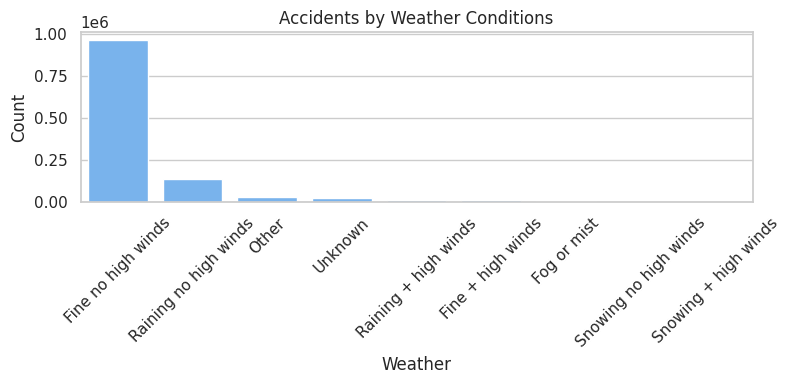

In [ ]:
# Count plot
plt.figure(figsize=(8,4))
sns.barplot(x=weather_counts.index, y=weather_counts.values, color='#66b3ff')
plt.title("Accidents by Weather Conditions")
plt.ylabel("Count")
plt.xlabel("Weather")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

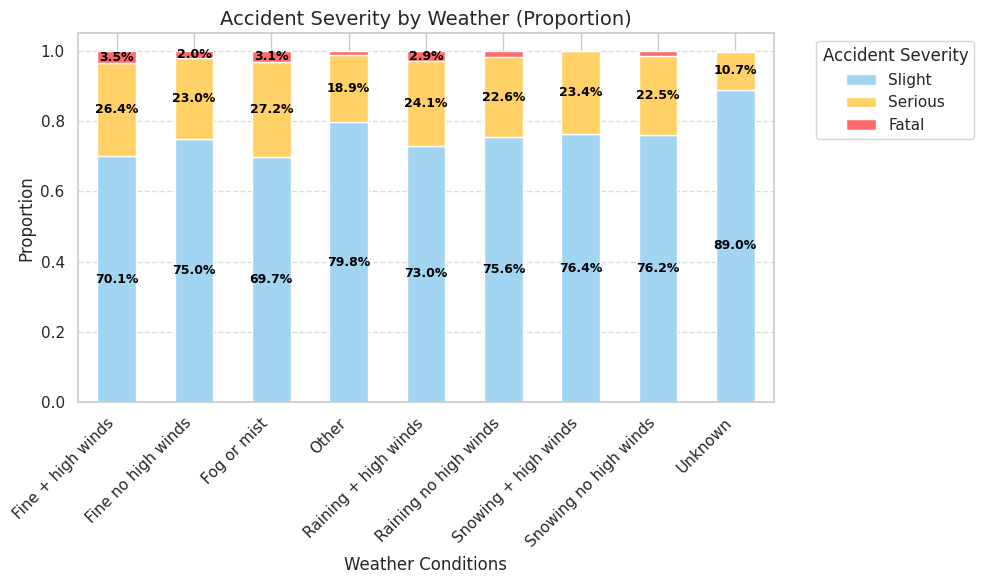

In [ ]:
# Stacked severity
pivot = weather_sev.pivot(index='weather_conditions', columns='accident_severity', values='within_prop').fillna(0)

# Ensure the columns are in the desired order for stacking
severity_order = ['Slight', 'Serious', 'Fatal']
pivot = pivot[severity_order]

# Create a figure and an axes object for better control over layout
fig, ax = plt.subplots(figsize=(10, 6))

pivot.plot(kind='bar', stacked=True,
                                         color=[severity_colors_map[s] for s in severity_order],
                                         ax=ax)
plt.title("Accident Severity by Weather (Proportion)", fontsize=14)
plt.ylabel("Proportion", fontsize=12)
plt.xlabel("Weather Conditions", fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Accident Severity', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=11, title_fontsize=12)

# Annotate each segment with percentage
for bar_group in ax.containers:
    for bar in bar_group:
        height = bar.get_height()
        if height > 0.02:  # Only annotate if segment is large enough to display
            ax.annotate(f'{height*100:.1f}%',
                        xy=(bar.get_x() + bar.get_width() / 2, bar.get_y() + height / 2),
                        ha='center',
                        va='center',
                        fontsize=9,
                        fontweight='bold',
                        color='black')

plt.tight_layout()
plt.show()

Most accidents happen in fine weather simply because more people drive in good weather. However, fine weather with high winds is surprisingly the most dangerous with a fatal rate of 3.5%, followed by fog at 3.1% and rain with high winds at 2.9%. Interestingly, snowing has a low fatal rate as drivers tend to be more careful in snow. This shows that wind and poor visibility are the real danger factors, not just rain or snow. Simply put, good weather does not always mean safe driving.

### Light Conditions

In [ ]:
# Overall counts
light_counts = df_clean['light_conditions'].value_counts()
print("Counts by Light Conditions:")
print(light_counts)

# Cross-tab with severity
light_sev = df_clean.groupby(['light_conditions','accident_severity']).size().reset_index(name='count')
light_sev['within_prop'] = light_sev.groupby('light_conditions')['count'].transform(lambda x: x / x.sum())
print("\nAccident severity by Light Conditions:")
print(light_sev)



Counts by Light Conditions:
light_conditions
Daylight                       864707
Darkness - lights lit          239065
Darkness - no lighting          65907
Darkness - lighting unknown     19281
Darkness - lights unlit          8387
Unknown                            58
Name: count, dtype: int64

Accident severity by Light Conditions:
               light_conditions accident_severity   count  within_prop
0   Darkness - lighting unknown             Fatal     444     0.023028
1   Darkness - lighting unknown           Serious    3043     0.157824
2   Darkness - lighting unknown            Slight   15794     0.819148
3         Darkness - lights lit             Fatal    3975     0.016627
4         Darkness - lights lit           Serious   54018     0.225955
5         Darkness - lights lit            Slight  181072     0.757417
6       Darkness - lights unlit             Fatal     265     0.031597
7       Darkness - lights unlit           Serious    2010     0.239657
8       Darkness - lig

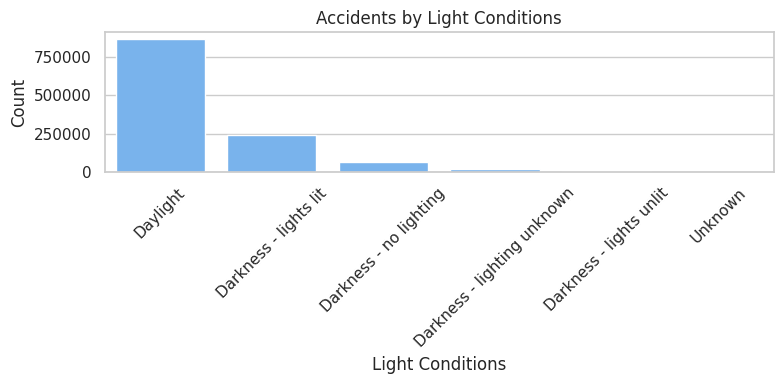

In [ ]:
# Count plot
plt.figure(figsize=(8,4))
sns.barplot(x=light_counts.index, y=light_counts.values, color='#66b3ff')
plt.title("Accidents by Light Conditions")
plt.ylabel("Count")
plt.xlabel("Light Conditions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

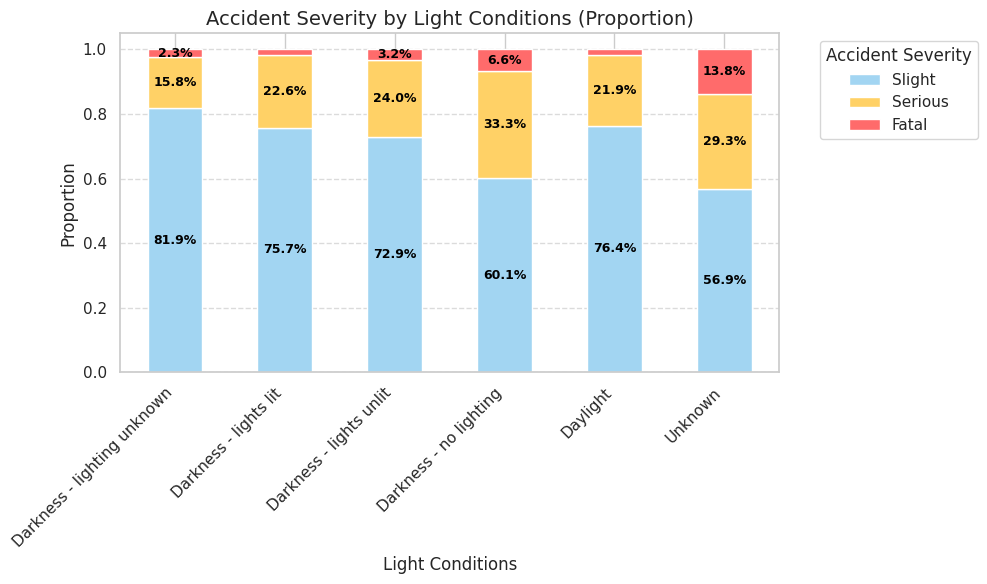

In [ ]:
# Stacked proportion plot
pivot = light_sev.pivot(index='light_conditions', columns='accident_severity', values='within_prop').fillna(0)

# Ensure the columns are in the desired order for stacking
severity_order = ['Slight', 'Serious', 'Fatal']
pivot = pivot[severity_order]

# Create a figure and an axes object for better control over layout
fig, ax = plt.subplots(figsize=(10, 6))

pivot.plot(kind='bar', stacked=True,
                                         color=[severity_colors_map[s] for s in severity_order],
                                         ax=ax)
plt.title("Accident Severity by Light Conditions (Proportion)", fontsize=14)
plt.ylabel("Proportion", fontsize=12)
plt.xlabel("Light Conditions", fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Accident Severity', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=11, title_fontsize=12)

# Annotate each segment with percentage
for bar_group in ax.containers:
    for bar in bar_group:
        height = bar.get_height()
        if height > 0.02:  # Only annotate if segment is large enough to display
            ax.annotate(f'{height*100:.1f}%',
                        xy=(bar.get_x() + bar.get_width() / 2, bar.get_y() + height / 2),
                        ha='center',
                        va='center',
                        fontsize=9,
                        fontweight='bold',
                        color='black')

plt.tight_layout()
plt.show()


Most accidents happen in daylight simply because more people drive during the day. However, darkness makes accidents far more deadly. Roads with no lighting at night have the highest fatal rate at 6.6%, which is almost 4 times higher than daylight at just 1.7%. Even roads with street lights at night have a higher fatal rate than daytime. This clearly shows that poor lighting is a major factor in deadly accidents. Simply put, driving in the dark, especially on unlit roads, is significantly more dangerous than driving in daylight.



### Road Surface Conditions

In [ ]:
# Counts
surface_counts = df_clean['road_surface_conditions'].value_counts()
print("Counts by Road Surface Conditions:")
print(surface_counts)

# Cross-tab
surface_sev = df_clean.groupby(['road_surface_conditions','accident_severity']).size().reset_index(name='count')
surface_sev['within_prop'] = surface_sev.groupby('road_surface_conditions')['count'].transform(lambda x: x / x.sum())
print("\nAccident severity by Road Surface Conditions:")
print(surface_sev)

Counts by Road Surface Conditions:
road_surface_conditions
Dry                     859254
Wet or damp             300719
Unknown                  18243
Frost or ice             14186
Snow                      3274
Flood over 3cm. deep      1729
Name: count, dtype: int64

Accident severity by Road Surface Conditions:
   road_surface_conditions accident_severity   count  within_prop
0                      Dry             Fatal   15977     0.018594
1                      Dry           Serious  194086     0.225877
2                      Dry            Slight  649191     0.755529
3     Flood over 3cm. deep             Fatal      66     0.038172
4     Flood over 3cm. deep           Serious     451     0.260844
5     Flood over 3cm. deep            Slight    1212     0.700983
6             Frost or ice             Fatal     193     0.013605
7             Frost or ice           Serious    3823     0.269491
8             Frost or ice            Slight   10170     0.716904
9                     

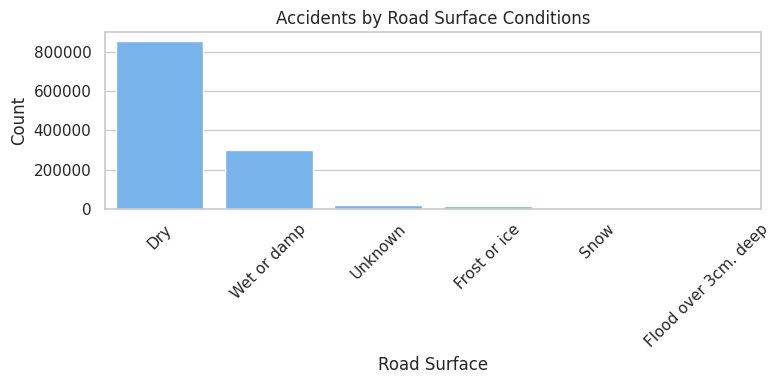

In [ ]:
# Count plot
plt.figure(figsize=(8,4))
sns.barplot(x=surface_counts.index, y=surface_counts.values, color='#66b3ff')
plt.title("Accidents by Road Surface Conditions")
plt.ylabel("Count")
plt.xlabel("Road Surface")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

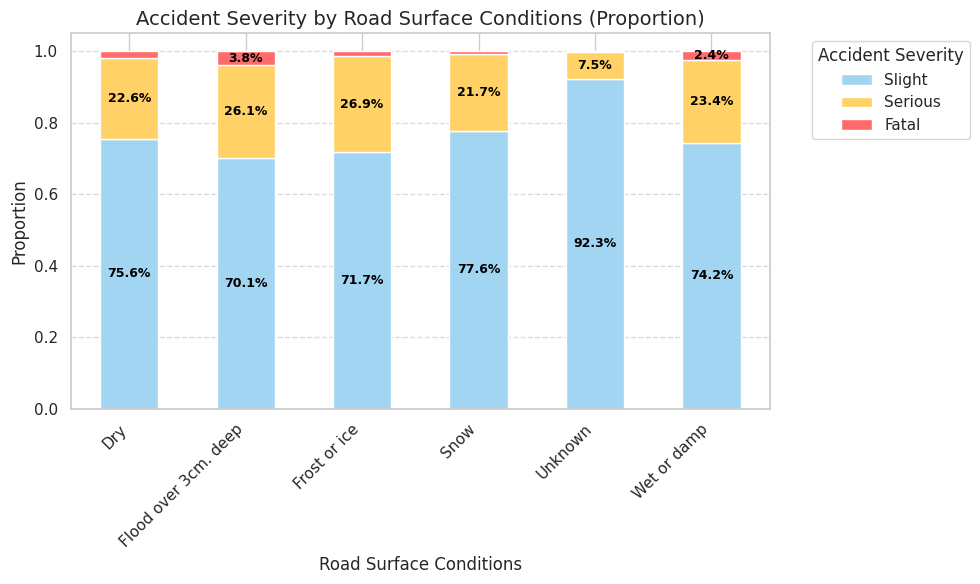

In [ ]:
# Stacked severity
pivot = surface_sev.pivot(index='road_surface_conditions', columns='accident_severity', values='within_prop').fillna(0)

# Ensure the columns are in the desired order for stacking
severity_order = ['Slight', 'Serious', 'Fatal']
pivot = pivot[severity_order]

# Create a figure and an axes object for better control over layout
fig, ax = plt.subplots(figsize=(10, 6))

pivot.plot(kind='bar', stacked=True,
                                         color=[severity_colors_map[s] for s in severity_order],
                                         ax=ax)
plt.title("Accident Severity by Road Surface Conditions (Proportion)", fontsize=14)
plt.ylabel("Proportion", fontsize=12)
plt.xlabel("Road Surface Conditions", fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Accident Severity', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=11, title_fontsize=12)

# Annotate each segment with percentage
for bar_group in ax.containers:
    for bar in bar_group:
        height = bar.get_height()
        if height > 0.02:  # Only annotate if segment is large enough to display
            ax.annotate(f'{height*100:.1f}%',
                        xy=(bar.get_x() + bar.get_width() / 2, bar.get_y() + height / 2),
                        ha='center',
                        va='center',
                        fontsize=9,
                        fontweight='bold',
                        color='black')

plt.tight_layout()
plt.show()

Most accidents happen on dry roads simply because that is the most common road condition. However, flooded roads are the most dangerous with a fatal rate of 3.8%, followed by wet or damp roads at 2.4%. Surprisingly, snow and frost have relatively low fatal rates, likely because drivers slow down and are more careful in those conditions. Dry roads have a low fatal rate of just 1.9% despite having the most accidents. This shows that water on the road, whether flooding or rain, is the biggest danger. Simply put, wet and flooded roads are far more deadly than snowy or icy ones.

### Junction Control

In [ ]:
# Counts
junction_counts = df_clean['junction_control'].value_counts()
print("Counts by Junction Control:")
print(junction_counts)

# Cross-tab
junction_sev = df_clean.groupby(['junction_control','accident_severity']).size().reset_index(name='count')
junction_sev['within_prop'] = junction_sev.groupby('junction_control')['count'].transform(lambda x: x / x.sum())
print("\nAccident severity by Junction Control:")
print(junction_sev)


Counts by Junction Control:
junction_control
Unknown                     532259
Give way or uncontrolled    518336
Auto traffic signal         133584
Stop sign                     8451
Authorised person             4775
Name: count, dtype: int64

Accident severity by Junction Control:
            junction_control accident_severity   count  within_prop
0          Authorised person             Fatal      26     0.005445
1          Authorised person           Serious     959     0.200838
2          Authorised person            Slight    3790     0.793717
3        Auto traffic signal             Fatal    1098     0.008220
4        Auto traffic signal           Serious   23260     0.174123
5        Auto traffic signal            Slight  109226     0.817658
6   Give way or uncontrolled             Fatal    6111     0.011790
7   Give way or uncontrolled           Serious  112832     0.217681
8   Give way or uncontrolled            Slight  399393     0.770529
9                  Stop sign      

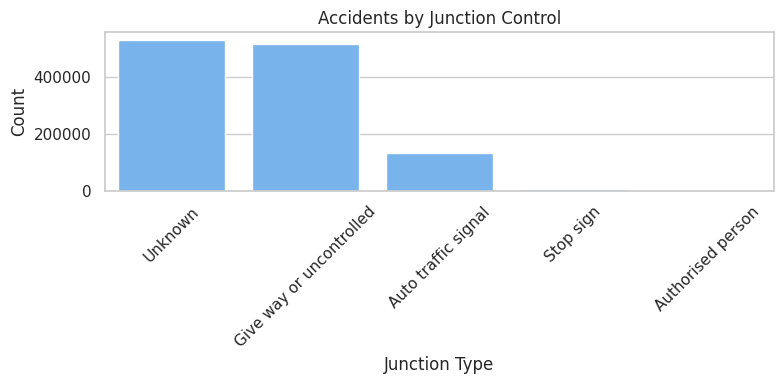

In [ ]:
# Count plot
plt.figure(figsize=(8,4))
sns.barplot(x=junction_counts.index, y=junction_counts.values, color='#66b3ff')
plt.title("Accidents by Junction Control")
plt.ylabel("Count")
plt.xlabel("Junction Type")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

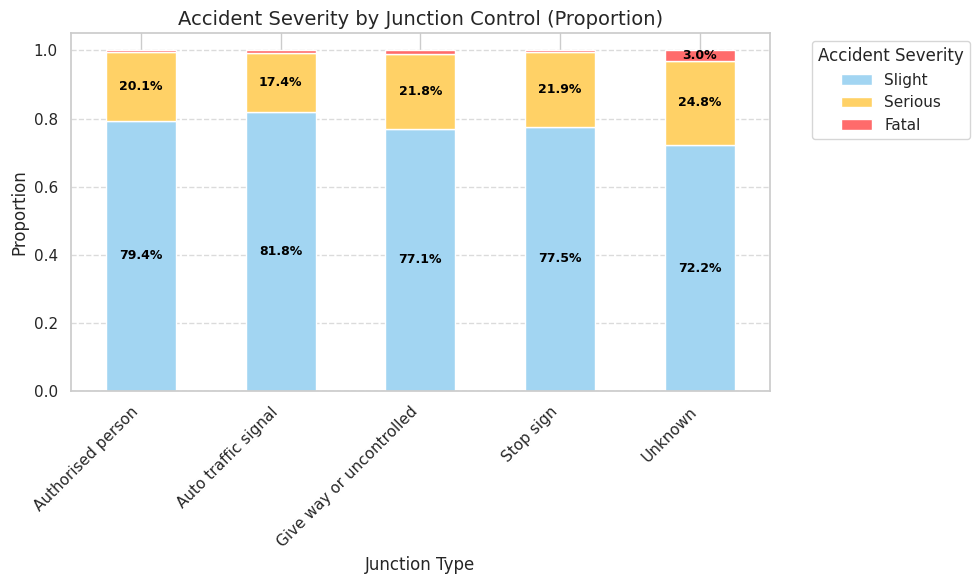

In [ ]:
# Stacked severity
pivot = junction_sev.pivot(index='junction_control', columns='accident_severity', values='within_prop').fillna(0)

# Ensure the columns are in the desired order for stacking
severity_order = ['Slight', 'Serious', 'Fatal']
pivot = pivot[severity_order]

# Create a figure and an axes object for better control over layout
fig, ax = plt.subplots(figsize=(10, 6))

pivot.plot(kind='bar', stacked=True,
           color=[severity_colors_map[s] for s in severity_order],
           ax=ax) # Pass ax to the plot function

plt.title("Accident Severity by Junction Control (Proportion)", fontsize=14)
plt.ylabel("Proportion", fontsize=12)
plt.xlabel("Junction Type", fontsize=12) # Changed x-axis label
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Accident Severity', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=11, title_fontsize=12) # Separate legend

# Annotate each segment with percentage
for bar_group in ax.containers:
    for bar in bar_group:
        height = bar.get_height()
        if height > 0.02:  # Only annotate if segment is large enough to display
            ax.annotate(f'{height*100:.1f}%',
                        xy=(bar.get_x() + bar.get_width() / 2, bar.get_y() + height / 2),
                        ha='center',
                        va='center',
                        fontsize=9,
                        fontweight='bold',
                        color='black')

plt.tight_layout()
plt.show()

Most accidents happen at give way or uncontrolled junctions simply because they are the most common. Traffic signals are the safest with the lowest fatal rate of just 0.8%, proving that proper traffic control saves lives. Uncontrolled junctions are more dangerous with a 1.2% fatal rate as there is no control over traffic flow. Simply put, better junction control means fewer deadly accidents.

## Spatial

In [ ]:
# Select relevant columns
spatial_df = df_clean[[ 'urban_or_rural_area',
                       'location_easting_osgr', 'location_northing_osgr', 'accident_severity']].copy()

# Ensure urban/rural is categorical
spatial_df['urban_or_rural_area'] = spatial_df['urban_or_rural_area'].astype(str).fillna('Unknown')

# Drop rows with missing coordinates
spatial_df = spatial_df.dropna(subset=['location_easting_osgr','location_northing_osgr'])

### Urban Rural

In [ ]:

# Counts
urban_counts = spatial_df['urban_or_rural_area'].value_counts()
print("Counts by Urban/Rural Area:\n", urban_counts)
# Cross-tab and within-group proportions
urban_sev = spatial_df.groupby(['urban_or_rural_area','accident_severity']).size().reset_index(name='count')
urban_sev['within_prop'] = urban_sev.groupby('urban_or_rural_area')['count'].transform(lambda x: x / x.sum())
print("\nAccident Severity by Urban/Rural Area:")
print(urban_sev)

Counts by Urban/Rural Area:
 urban_or_rural_area
Urban          749248
Rural          448002
Unallocated       142
Unknown            13
Name: count, dtype: int64

Accident Severity by Urban/Rural Area:
   urban_or_rural_area accident_severity   count  within_prop
0                Rural             Fatal   16677     0.037225
1                Rural           Serious  124625     0.278180
2                Rural            Slight  306700     0.684595
3          Unallocated             Fatal       1     0.007042
4          Unallocated           Serious      33     0.232394
5          Unallocated            Slight     108     0.760563
6              Unknown           Serious       3     0.230769
7              Unknown            Slight      10     0.769231
8                Urban             Fatal    6763     0.009026
9                Urban           Serious  146080     0.194969
10               Urban            Slight  596405     0.796005


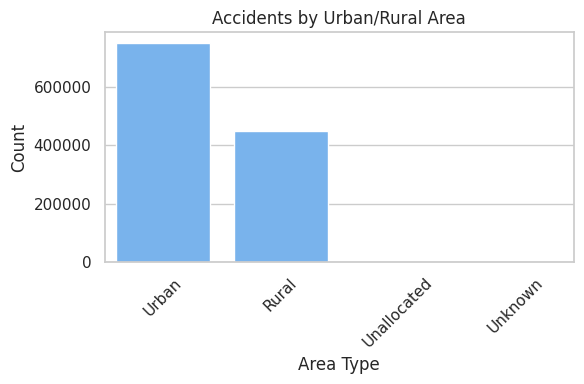

In [ ]:


# Bar plot
plt.figure(figsize=(6,4))
sns.barplot(x=urban_counts.index, y=urban_counts.values, color='#66b3ff')
plt.title("Accidents by Urban/Rural Area")
plt.ylabel("Count")
plt.xlabel("Area Type")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

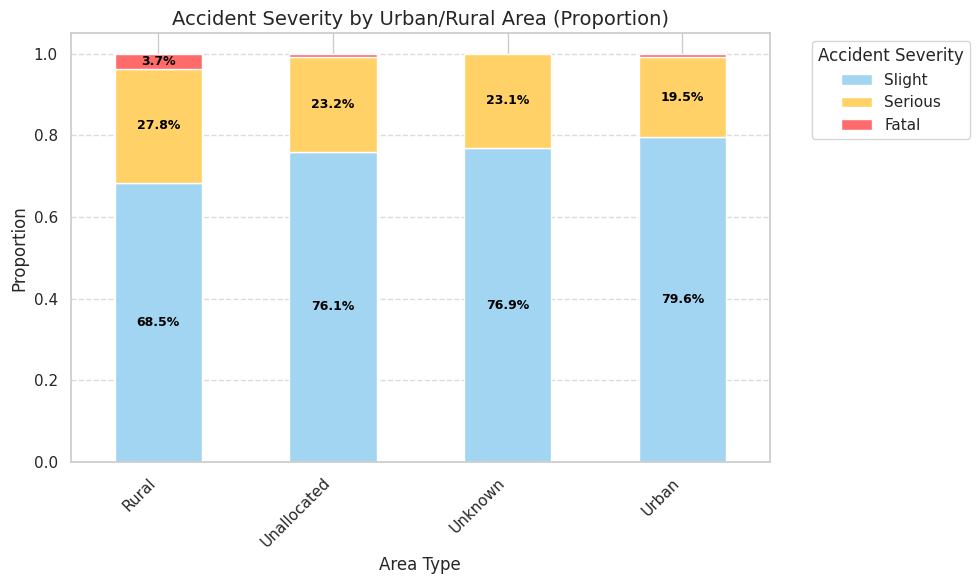

In [ ]:
# Stacked proportion plot
pivot = urban_sev.pivot(index='urban_or_rural_area', columns='accident_severity', values='within_prop').fillna(0)

# Ensure the columns are in the desired order for stacking
severity_order = ['Slight', 'Serious', 'Fatal']
pivot = pivot[severity_order]

# Create a figure and an axes object for better control over layout
fig, ax = plt.subplots(figsize=(10, 6))

pivot.plot(kind='bar', stacked=True,
                                         color=[severity_colors_map[s] for s in severity_order],
                                         ax=ax)
plt.title("Accident Severity by Urban/Rural Area (Proportion)", fontsize=14)
plt.ylabel("Proportion", fontsize=12)
plt.xlabel("Area Type", fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Accident Severity', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=11, title_fontsize=12)

# Annotate each segment with percentage
for bar_group in ax.containers:
    for bar in bar_group:
        height = bar.get_height()
        if height > 0.02:  # Only annotate if segment is large enough to display
            ax.annotate(f'{height*100:.1f}%',
                        xy=(bar.get_x() + bar.get_width() / 2, bar.get_y() + height / 2),
                        ha='center',
                        va='center',
                        fontsize=9,
                        fontweight='bold',
                        color='black')

plt.tight_layout()
plt.show()

Most accidents happen in urban areas simply because there are more people and vehicles in cities. However, rural areas are far more dangerous. Rural accidents have a fatal rate of 3.7%, which is four times higher than urban areas at just 0.9%. This is likely because rural roads have higher speed limits, less lighting, and are farther from emergency services. In simple words, urban areas have more accidents but rural roads are much more deadly.

### Latitude/Longitude


We have to convert British grid coordinates into standard GPS longitude and latitude values so that accident locations can be plotted on a map.

In [ ]:

# Initialize transformer: OSGR -> WGS84
transformer = Transformer.from_crs("EPSG:27700", "EPSG:4326", always_xy=True)

# Convert coordinates
spatial_df['longitude'], spatial_df['latitude'] = transformer.transform(
    spatial_df['location_easting_osgr'].values,
    spatial_df['location_northing_osgr'].values
)

# Check the first few rows
spatial_df[['location_easting_osgr','location_northing_osgr','longitude','latitude']].head()

,location_easting_osgr,location_northing_osgr,longitude,latitude
0,445240.0,517608.0,-1.302082,54.551706
1,445551.0,516373.0,-1.297465,54.540580
2,445551.0,516373.0,-1.297465,54.540580
3,445551.0,516373.0,-1.297465,54.540580
4,444050.0,518602.0,-1.320330,54.560743


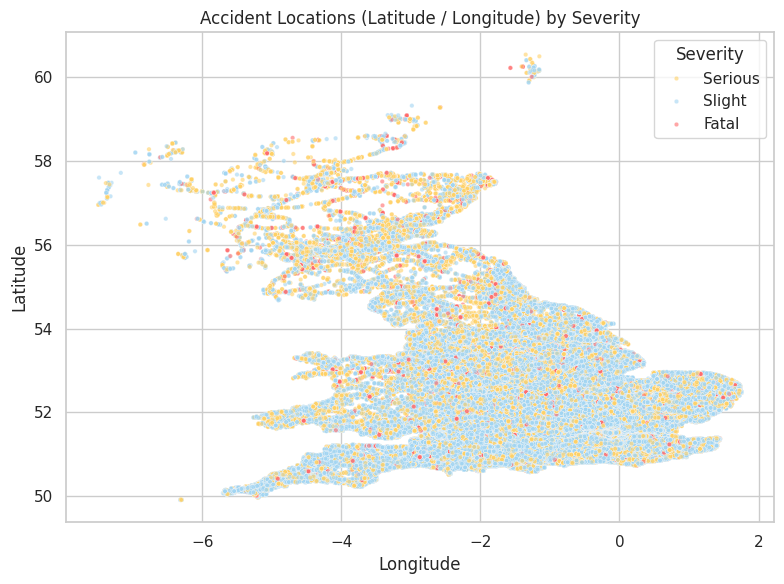

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=spatial_df,
                x='longitude',
                y='latitude',
                hue='accident_severity',
                palette=severity_colors_map,
                alpha=0.6, s=10)
plt.title("Accident Locations (Latitude / Longitude) by Severity")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(title='Severity')
plt.tight_layout()
plt.show()

It  plots all road accidents across the country, showing that most accidents are minor and happen in busy, populated areas in the south and center. Serious accidents are spread throughout the country, while fatal accidents are fewer in number but can occur anywhere. Simply put, more people and more traffic means more accidents.

# Machine Learning Evaluation

## Encode Target Variable

In [ ]:
le = LabelEncoder()
df_clean['accident_severity'] = le.fit_transform(df_clean['accident_severity'])

print("Target classes:", le.classes_)
print("Encoded values:", df_clean['accident_severity'].value_counts())


Target classes: ['Fatal' 'Serious' 'Slight']
Encoded values: accident_severity
2    903223
1    270741
0     23441
Name: count, dtype: int64


## Feature Engineering

In [ ]:
# Drop the problematic object-type columns that were created during EDA
# as LightGBM expects int, float or bool for non-categorical features.
columns_to_drop_from_X = [
    'hour_bin',
    'day_of_week_full',
    'month_full'
]

# Ensure these columns exist before trying to drop them
existing_cols_to_drop = [col for col in columns_to_drop_from_X if col in df_clean.columns]

if existing_cols_to_drop:
    df_clean = df_clean.drop(columns=existing_cols_to_drop, errors='ignore')
    print(f"Dropped problematic columns from df_clean: {existing_cols_to_drop}")
else:
    print("No problematic columns to drop.")

print("df_clean columns after dropping:", df_clean.columns.tolist())

Dropped problematic columns from df_clean: ['hour_bin', 'day_of_week_full', 'month_full']
df_clean columns after dropping: ['accident_severity', 'location_easting_osgr', 'location_northing_osgr', 'road_type', 'speed_limit', 'urban_or_rural_area', 'driver_age', 'driver_sex', 'casualty_age', 'casualty_sex', 'casualty_class', 'casualty_type', 'weather_conditions', 'light_conditions', 'road_surface_conditions', 'junction_control', 'towing_and_articulation', 'vehicle_type', 'driver_distance_banding', 'accident_year', 'hour', 'day_of_week', 'month', 'season']


## Define Feature and Target

In [ ]:
# Step 1: Define Features and Target
X = df_clean.drop('accident_severity', axis=1)
y = df_clean['accident_severity']

cat_cols = [
    'road_type', 'speed_limit', 'urban_or_rural_area', 'driver_sex',
    'casualty_sex', 'casualty_class', 'casualty_type', 'weather_conditions',
    'light_conditions', 'road_surface_conditions', 'junction_control',
    'towing_and_articulation', 'vehicle_type', 'driver_distance_banding',
    'day_of_week', 'month', 'season'
]

for col in cat_cols:
    X[col] = X[col].astype('category')

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1197405, 23)
y shape: (1197405,)


## Train Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (957924, 23)
X_test shape: (239481, 23)
y_train shape: (957924,)
y_test shape: (239481,)


## Train LightGBM model

In [ ]:
# Best parameters from Optuna
weights = {0: 10, 1: 3, 2: 1}
model_lgb = lgb.LGBMClassifier(
    n_estimators=212,
    learning_rate=0.09556428757689246,
    max_depth=7,
    num_leaves=44,
    min_child_samples=32,
    subsample=0.662397808134481,
    colsample_bytree=0.6232334448672797,
    class_weight=weights,
    random_state=42,
    n_jobs=-1
)

model_lgb.fit(
    X_train, y_train,
    categorical_feature=cat_cols
)
print("LightGBM training complete")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.273881 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 879
[LightGBM] [Info] Number of data points in the train set: 957924, number of used features: 23
[LightGBM] [Info] Start training from score -2.118430
[LightGBM] [Info] Start training from score -0.875736
[LightGBM] [Info] Start training from score -0.769543
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No 

## Evaluation

In [ ]:
# Predictions
y_pred_lgb = model_lgb.predict(X_test)
y_proba_lgb = model_lgb.predict_proba(X_test)

print("\nLightGBM Accuracy:", accuracy_score(y_test, y_pred_lgb))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lgb,
      target_names=['Fatal', 'Serious', 'Slight']))


LightGBM Accuracy: 0.6772186520016201

Classification Report:
              precision    recall  f1-score   support

       Fatal       0.31      0.31      0.31      4688
     Serious       0.38      0.60      0.47     54148
      Slight       0.86      0.71      0.78    180645

    accuracy                           0.68    239481
   macro avg       0.52      0.54      0.52    239481
weighted avg       0.74      0.68      0.70    239481



## Confusion Matrix

In [ ]:
# Calculate confusion matrix for LightGBM
cm_lgb = confusion_matrix(y_test, y_pred_lgb)

# Calculate class-wise accuracy
class_acc_lgb = cm_lgb.diagonal() / cm_lgb.sum(axis=1)

print("Fatal Accuracy:  ", round(class_acc_lgb[0] * 100, 2), "%")
print("Serious Accuracy:", round(class_acc_lgb[1] * 100, 2), "%")
print("Slight Accuracy: ", round(class_acc_lgb[2] * 100, 2), "%")

Fatal Accuracy:   31.02 %
Serious Accuracy: 60.01 %
Slight Accuracy:  70.99 %


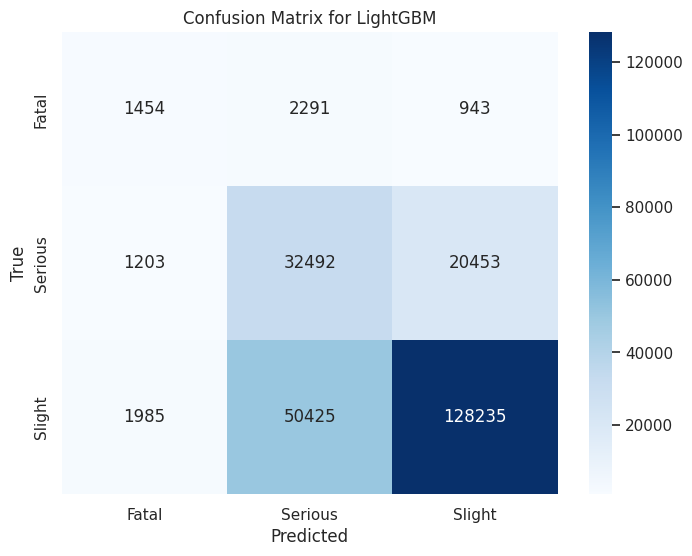

In [ ]:
cm = confusion_matrix(y_test, y_pred_lgb)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix for LightGBM')
plt.show()

## Roc Curve

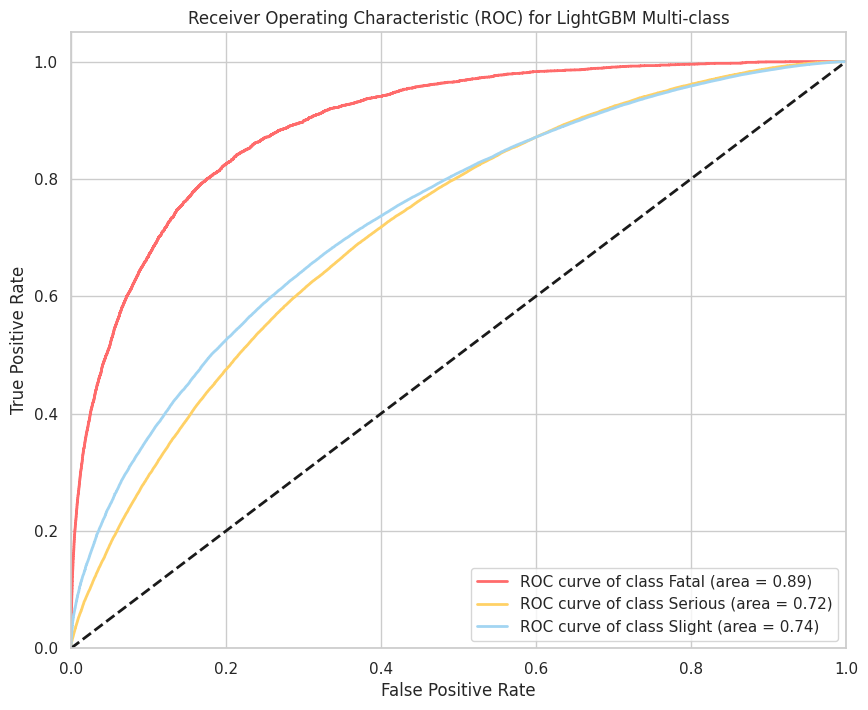

In [ ]:
# Binarize y_test for ROC curve calculation (one-vs-rest)
y_test_binarized = label_binarize(y_test, classes=model_lgb.classes_)
n_classes = y_test_binarized.shape[1]

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_binarized[:, i], y_proba_lgb[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot all ROC curves
plt.figure(figsize=(10, 8))
colors = ['#FF6B6B', '#FFD166', '#A2D5F2'] # Fatal, Serious, Slight
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label='ROC curve of class {0} (area = {1:0.2f})'
             ''.format(le.classes_[i], roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) for LightGBM Multi-class')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

## Feature Importance

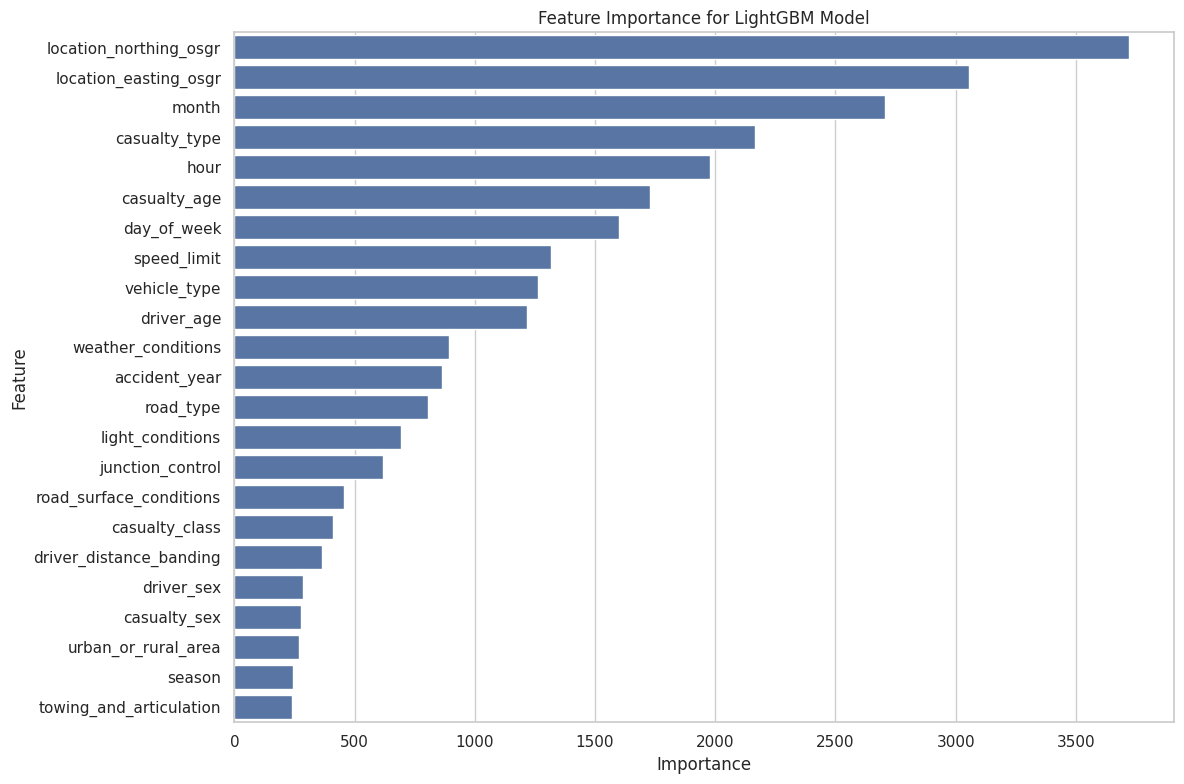

In [ ]:
feature_importances_lgb = model_lgb.feature_importances_
feature_names_lgb = X_train.columns

importance_df_lgb = pd.DataFrame({
    'Feature': feature_names_lgb,
    'Importance': feature_importances_lgb
})

importance_df_lgb = importance_df_lgb.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df_lgb)
plt.title('Feature Importance for LightGBM Model')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## Train CatBoost Model

In [ ]:
# Get categorical column indices
cat_features_idx = [X_train.columns.get_loc(col) for col in cat_cols]

model_cat = CatBoostClassifier(
    iterations=300,
    learning_rate=0.05,
    depth=6,
    class_weights={0: 10, 1: 3, 2: 1},
    cat_features=cat_features_idx,
    random_seed=42,
    task_type='GPU',
    verbose=50
)

model_cat.fit(
    X_train, y_train,
    eval_set=(X_test, y_test)
)
print("CatBoost training complete")

0:	learn: 1.0856654	test: 1.0856442	best: 1.0856442 (0)	total: 33.1ms	remaining: 9.9s
50:	learn: 0.8880428	test: 0.8869356	best: 0.8869356 (50)	total: 3.92s	remaining: 19.1s
100:	learn: 0.8639950	test: 0.8642378	best: 0.8642378 (100)	total: 5.46s	remaining: 10.8s
150:	learn: 0.8535353	test: 0.8542648	best: 0.8542648 (150)	total: 7.62s	remaining: 7.51s
200:	learn: 0.8461416	test: 0.8477564	best: 0.8477564 (200)	total: 10.5s	remaining: 5.17s
250:	learn: 0.8405417	test: 0.8429880	best: 0.8429880 (250)	total: 12.9s	remaining: 2.51s
299:	learn: 0.8357122	test: 0.8389293	best: 0.8389293 (299)	total: 18s	remaining: 0us
bestTest = 0.8389292642
bestIteration = 299
CatBoost training complete


In [ ]:
# Predictions
y_pred_cat = model_cat.predict(X_test)
y_proba_cat = model_cat.predict_proba(X_test)

print("\nCatBoost Accuracy:", accuracy_score(y_test, y_pred_cat))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_cat,
      target_names=['Fatal', 'Serious', 'Slight']))

cm_cat = confusion_matrix(y_test, y_pred_cat)
class_acc_cat = cm_cat.diagonal() / cm_cat.sum(axis=1)
print("Fatal Accuracy:  ", round(class_acc_cat[0] * 100, 2), "%")
print("Serious Accuracy:", round(class_acc_cat[1] * 100, 2), "%")
print("Slight Accuracy: ", round(class_acc_cat[2] * 100, 2), "%")


CatBoost Accuracy: 0.6652385784258459

Classification Report:
              precision    recall  f1-score   support

       Fatal       0.21      0.16      0.18      4688
     Serious       0.36      0.55      0.43     54148
      Slight       0.84      0.71      0.77    180645

    accuracy                           0.67    239481
   macro avg       0.47      0.47      0.46    239481
weighted avg       0.72      0.67      0.68    239481

Fatal Accuracy:   15.72 %
Serious Accuracy: 55.16 %
Slight Accuracy:  71.25 %


In [ ]:
## Find BEst Parameters
def objective_cat(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 200, 600),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
        'depth': trial.suggest_int('depth', 4, 10),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0, 1),
        'class_weights': {0: 15, 1: 4, 2: 1},
        'cat_features': cat_features_idx,
        'random_seed': 42,
        'task_type': 'GPU',
        'verbose': 0
    }

    model = CatBoostClassifier(**params)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    return f1_score(y_test, y_pred, average='macro')

# Run 10 trials
sampler = TPESampler(seed=42)
study_cat = optuna.create_study(direction='maximize', sampler=sampler)
study_cat.optimize(objective_cat, n_trials=10, show_progress_bar=True)

print("\nBest CatBoost Parameters:")
print(study_cat.best_params)
print(f"Best Macro F1: {study_cat.best_value:.3f}")


[I 2026-03-15 16:02:48,672] A new study created in memory with name: no-name-d4318be2-1a98-422b-a7d2-07d02f60212b


  0%|          | 0/10 [00:00<?, ?it/s]

[I 2026-03-15 16:03:32,013] Trial 0 finished with value: 0.5173970151680934 and parameters: {'iterations': 350, 'learning_rate': 0.09556428757689246, 'depth': 9, 'l2_leaf_reg': 6.387926357773329, 'bagging_temperature': 0.15601864044243652}. Best is trial 0 with value: 0.5173970151680934.
[I 2026-03-15 16:04:08,913] Trial 1 finished with value: 0.42110785629734065 and parameters: {'iterations': 262, 'learning_rate': 0.015227525095137952, 'depth': 10, 'l2_leaf_reg': 6.41003510568888, 'bagging_temperature': 0.7080725777960455}. Best is trial 0 with value: 0.5173970151680934.
[I 2026-03-15 16:04:29,966] Trial 2 finished with value: 0.4957635521370504 and parameters: {'iterations': 208, 'learning_rate': 0.0972918866945795, 'depth': 9, 'l2_leaf_reg': 2.9110519961044856, 'bagging_temperature': 0.18182496720710062}. Best is trial 0 with value: 0.5173970151680934.
[I 2026-03-15 16:04:50,201] Trial 3 finished with value: 0.43285702137722737 and parameters: {'iterations': 273, 'learning_rate': 0.

In [ ]:
# Retrain CatBoost with best parameters
best_cat_params = {
    'iterations': 350,
    'learning_rate': 0.09556428757689246,
    'depth': 9,
    'l2_leaf_reg': 6.387926357773329,
    'bagging_temperature': 0.15601864044243652,
    'class_weights': {0: 15, 1: 4, 2: 1},
    'cat_features': cat_features_idx,
    'random_seed': 42,
    'task_type': 'GPU',
    'verbose': 50
}

model_cat_tuned = CatBoostClassifier(**best_cat_params)
model_cat_tuned.fit(
    X_train, y_train,
    eval_set=(X_test, y_test)
)
print("Tuned CatBoost training complete")

# Predictions
y_pred_cat_tuned = model_cat_tuned.predict(X_test)
y_proba_cat_tuned = model_cat_tuned.predict_proba(X_test)

print("\nTuned CatBoost Accuracy:", accuracy_score(y_test, y_pred_cat_tuned))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_cat_tuned,
      target_names=['Fatal', 'Serious', 'Slight']))

# Class accuracy
cm_cat_tuned = confusion_matrix(y_test, y_pred_cat_tuned)
class_acc_cat = cm_cat_tuned.diagonal() / cm_cat_tuned.sum(axis=1)
print("Fatal Accuracy:  ", round(class_acc_cat[0] * 100, 2), "%")
print("Serious Accuracy:", round(class_acc_cat[1] * 100, 2), "%")
print("Slight Accuracy: ", round(class_acc_cat[2] * 100, 2), "%")

0:	learn: 1.0777284	test: 1.0777990	best: 1.0777990 (0)	total: 71.1ms	remaining: 24.8s
50:	learn: 0.8692375	test: 0.8740972	best: 0.8740972 (50)	total: 2.47s	remaining: 14.5s
100:	learn: 0.8348035	test: 0.8467064	best: 0.8467064 (100)	total: 4.71s	remaining: 11.6s
150:	learn: 0.8061687	test: 0.8254377	best: 0.8254377 (150)	total: 7.02s	remaining: 9.25s
200:	learn: 0.7848281	test: 0.8100022	best: 0.8100022 (200)	total: 9.35s	remaining: 6.93s
250:	learn: 0.7679118	test: 0.7986145	best: 0.7986145 (250)	total: 14.3s	remaining: 5.64s
300:	learn: 0.7505563	test: 0.7864868	best: 0.7864868 (300)	total: 16.6s	remaining: 2.71s
349:	learn: 0.7383114	test: 0.7782179	best: 0.7782179 (349)	total: 18.9s	remaining: 0us
bestTest = 0.7782178831
bestIteration = 349
Tuned CatBoost training complete

Tuned CatBoost Accuracy: 0.6092049056083781

Classification Report:
              precision    recall  f1-score   support

       Fatal       0.34      0.45      0.39      4688
     Serious       0.34      0.7

## Confusion Matrix

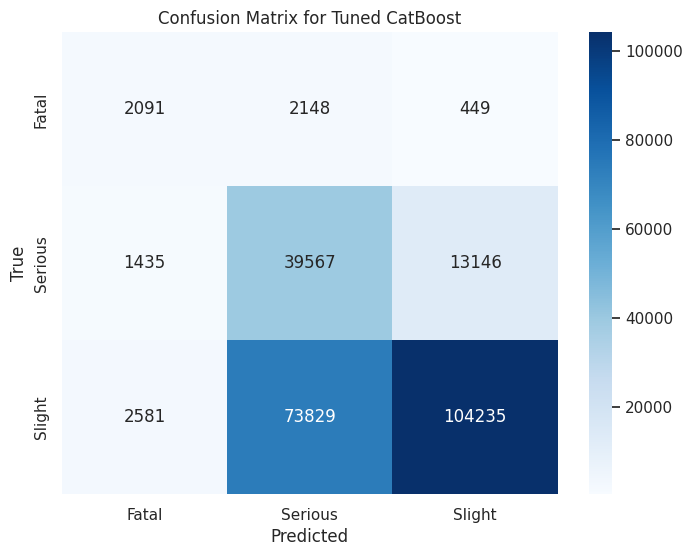

In [ ]:
cm = confusion_matrix(y_test, y_pred_cat_tuned)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix for Tuned CatBoost')
plt.show()

## ROC Curve

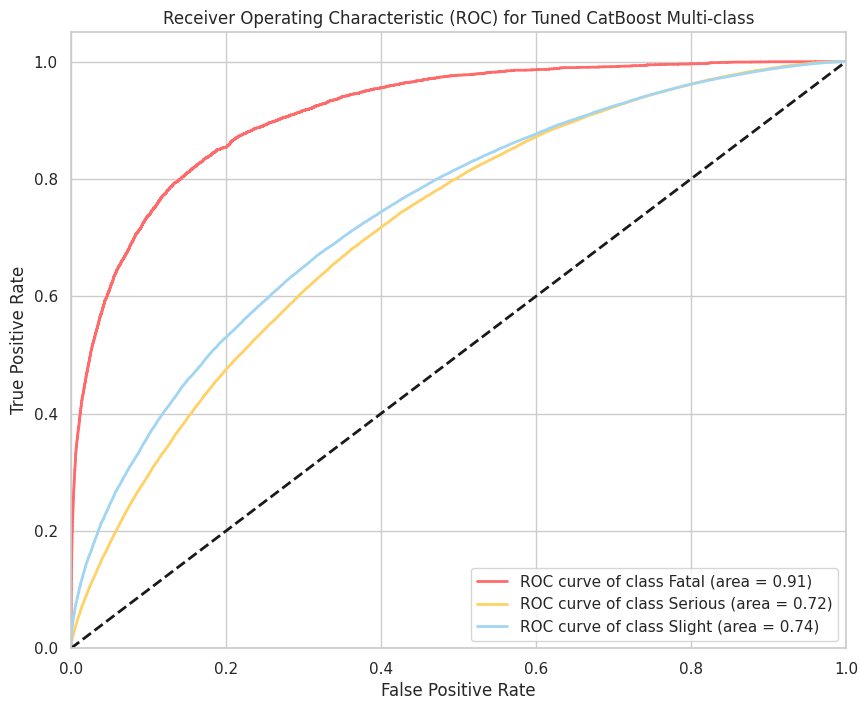

In [ ]:
# Binarize y_test for ROC curve calculation (one-vs-rest)
y_test_binarized = label_binarize(y_test, classes=model_cat_tuned.classes_)
n_classes = y_test_binarized.shape[1]

# Compute ROC curve and ROC area for each class
fpr_cat = dict()
tpr_cat = dict()
roc_auc_cat = dict()
for i in range(n_classes):
    fpr_cat[i], tpr_cat[i], _ = roc_curve(y_test_binarized[:, i], y_proba_cat_tuned[:, i])
    roc_auc_cat[i] = auc(fpr_cat[i], tpr_cat[i])

# Plot all ROC curves
plt.figure(figsize=(10, 8))
colors = ['#FF6B6B', '#FFD166', '#A2D5F2'] # Fatal, Serious, Slight
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr_cat[i], tpr_cat[i], color=color, lw=2,
             label='ROC curve of class {0} (area = {1:0.2f})'
             ''.format(le.classes_[i], roc_auc_cat[i]))

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) for Tuned CatBoost Multi-class')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

## Feature Importance

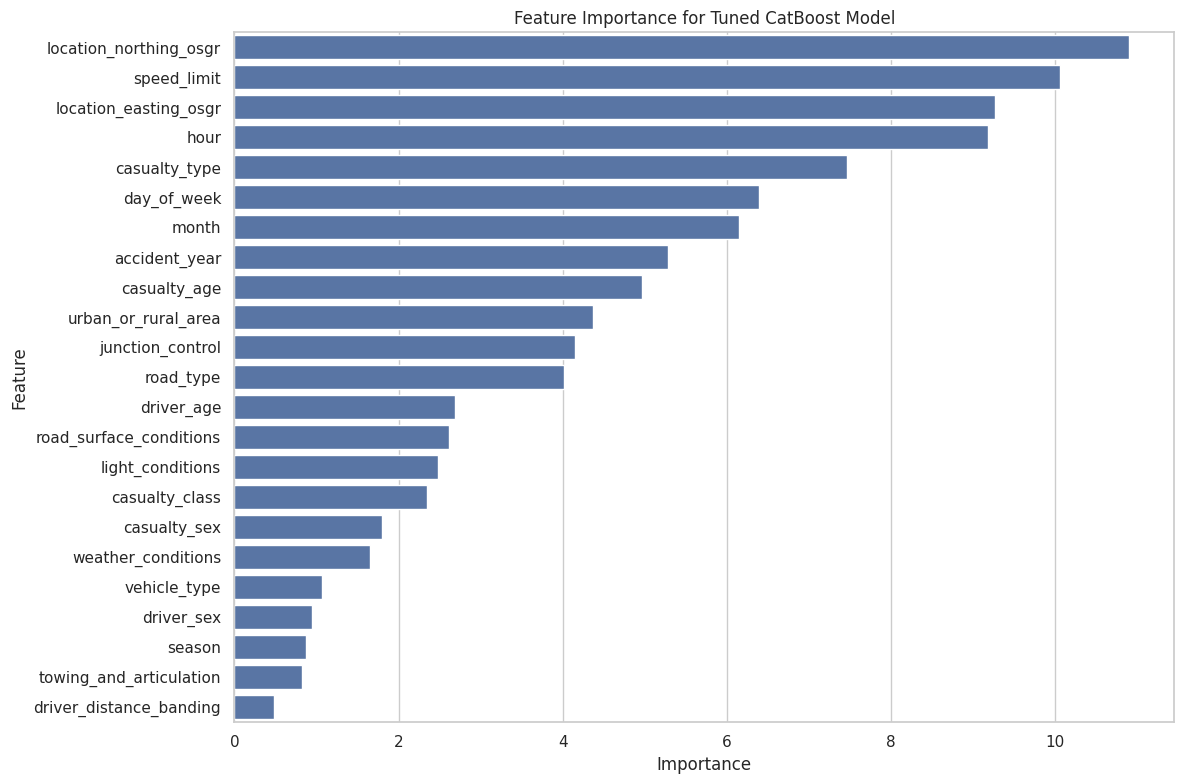

In [ ]:
feature_importances = model_cat_tuned.get_feature_importance()
feature_names = X_train.columns

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
})

importance_df = importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Feature Importance for Tuned CatBoost Model')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## Comparison

Metric                        LightGBM     CatBoost     Ensemble
Overall Accuracy                0.6772       0.6092       0.6484
Fatal Accuracy                  31.02%       44.60%       38.80%
Serious Accuracy                60.01%       73.07%       67.40%
Slight Accuracy                 70.99%       57.70%       64.75%
Macro F1                        0.5182       0.5174       0.5322
Macro ROC AUC                   0.7837       0.7915       0.7916


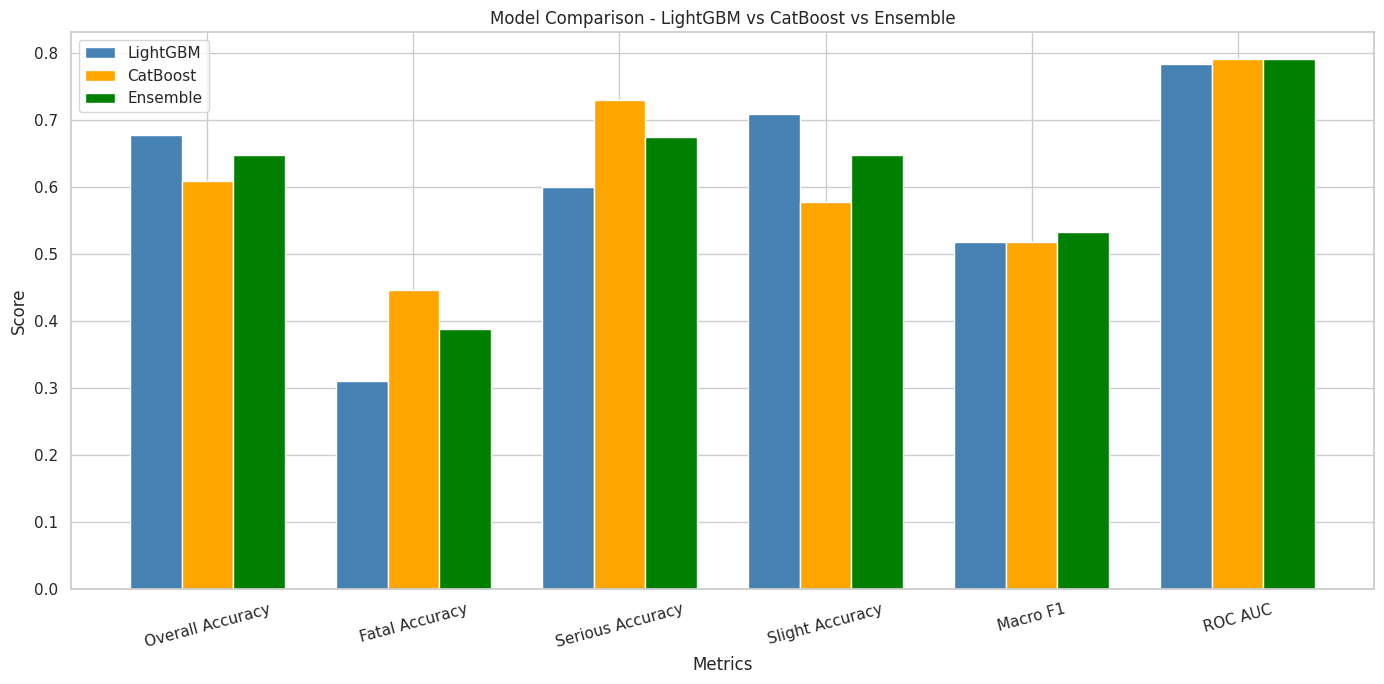

In [ ]:
# ============================================================
# FINAL MODEL COMPARISON
# ============================================================

# LightGBM Metrics
cm_lgb = confusion_matrix(y_test, y_pred_lgb)
class_acc_lgb = cm_lgb.diagonal() / cm_lgb.sum(axis=1)
roc_lgb = roc_auc_score(y_test, y_proba_lgb, multi_class='ovr', average='macro')

# CatBoost Metrics
cm_cat = confusion_matrix(y_test, y_pred_cat_tuned)
class_acc_cat = cm_cat.diagonal() / cm_cat.sum(axis=1)
roc_cat = roc_auc_score(y_test, y_proba_cat_tuned, multi_class='ovr', average='macro')

# Ensemble Metrics
y_proba_ensemble = (y_proba_lgb * 0.5) + (y_proba_cat_tuned * 0.5)
y_pred_ensemble = np.argmax(y_proba_ensemble, axis=1)
cm_ens = confusion_matrix(y_test, y_pred_ensemble)
class_acc_ens = cm_ens.diagonal() / cm_ens.sum(axis=1)
roc_ens = roc_auc_score(y_test, y_proba_ensemble, multi_class='ovr', average='macro')

# ============================================================
# COMPARISON TABLE
# ============================================================
print("=" * 65)
print(f"{'Metric':<25} {'LightGBM':>12} {'CatBoost':>12} {'Ensemble':>12}")
print("=" * 65)
print(f"{'Overall Accuracy':<25} {accuracy_score(y_test, y_pred_lgb):>12.4f} {accuracy_score(y_test, y_pred_cat_tuned):>12.4f} {accuracy_score(y_test, y_pred_ensemble):>12.4f}")
print(f"{'Fatal Accuracy':<25} {class_acc_lgb[0]*100:>11.2f}% {class_acc_cat[0]*100:>11.2f}% {class_acc_ens[0]*100:>11.2f}%")
print(f"{'Serious Accuracy':<25} {class_acc_lgb[1]*100:>11.2f}% {class_acc_cat[1]*100:>11.2f}% {class_acc_ens[1]*100:>11.2f}%")
print(f"{'Slight Accuracy':<25} {class_acc_lgb[2]*100:>11.2f}% {class_acc_cat[2]*100:>11.2f}% {class_acc_ens[2]*100:>11.2f}%")
print(f"{'Macro F1':<25} {f1_score(y_test, y_pred_lgb, average='macro'):>12.4f} {f1_score(y_test, y_pred_cat_tuned, average='macro'):>12.4f} {f1_score(y_test, y_pred_ensemble, average='macro'):>12.4f}")
print(f"{'Macro ROC AUC':<25} {roc_lgb:>12.4f} {roc_cat:>12.4f} {roc_ens:>12.4f}")
print("=" * 65)

# ============================================================
# COMPARISON BAR CHART
# ============================================================
metrics = ['Overall Accuracy', 'Fatal Accuracy', 'Serious Accuracy', 'Slight Accuracy', 'Macro F1', 'ROC AUC']
lgb_scores = [
    accuracy_score(y_test, y_pred_lgb),
    class_acc_lgb[0],
    class_acc_lgb[1],
    class_acc_lgb[2],
    f1_score(y_test, y_pred_lgb, average='macro'),
    roc_lgb
]
cat_scores = [
    accuracy_score(y_test, y_pred_cat_tuned),
    class_acc_cat[0],
    class_acc_cat[1],
    class_acc_cat[2],
    f1_score(y_test, y_pred_cat_tuned, average='macro'),
    roc_cat
]
ens_scores = [
    accuracy_score(y_test, y_pred_ensemble),
    class_acc_ens[0],
    class_acc_ens[1],
    class_acc_ens[2],
    f1_score(y_test, y_pred_ensemble, average='macro'),
    roc_ens
]

x = np.arange(len(metrics))
width = 0.25

plt.figure(figsize=(14, 7))
plt.bar(x - width, lgb_scores, width, label='LightGBM', color='steelblue')
plt.bar(x, cat_scores, width, label='CatBoost', color='orange')
plt.bar(x + width, ens_scores, width, label='Ensemble', color='green')

plt.xlabel('Metrics')
plt.ylabel('Score')
plt.title('Model Comparison - LightGBM vs CatBoost vs Ensemble')
plt.xticks(x, metrics, rotation=15)
plt.legend()
plt.tight_layout()
plt.show()

The model comparison table shows the performance of LightGBM, CatBoost, and an Ensemble model. LightGBM achieved the highest overall accuracy at 67.72%, while CatBoost showed superior accuracy in predicting 'Fatal' (44.60%) and 'Serious' (73.07%) accidents. The Ensemble model, which combined both, delivered the best balance with the highest Macro F1 score (0.5322) and Macro ROC AUC (0.7916), making it the chosen best performer for predicting accident severity across all classes.